# Proyecto de Clasificación — Predicción de Aprobación de Préstamos (Loan Risk Prediction)

## Introducción y Objetivos

Este proyecto aborda un problema de **clasificación binaria**: predecir si una
solicitud de préstamo será **aprobada (1)** o **rechazada (0)** a partir de
las características socioeconómicas del solicitante (edad, ingresos, importe
solicitado, historial crediticio, experiencia laboral, nivel educativo,
ciudad y situación laboral).

El objetivo final es doble:
1. **Analítico**: construir, comparar y optimizar varios modelos de
   clasificación, manteniendo el **overfitting por debajo del 5%** (requisito
   del proyecto).
2. **Productivo**: dejar el modelo final exportado y listo para ser
   consumido por una aplicación (Streamlit) que reciba los datos de un
   cliente nuevo y devuelva la predicción, junto con el resto de
   componentes de nivel Medio/Avanzado (validación cruzada, tuning de
   hiperparámetros, sistema de feedback, ingesta de datos nuevos,
   dockerización, base de datos y tests unitarios).

### Dataset
`data/loan_risk_prediction_dataset.csv` — 5.000 solicitudes de préstamo con
las siguientes columnas:

| Columna | Descripción |
|---|---|
| `Age` | Edad del solicitante |
| `Income` | Ingresos anuales (USD) |
| `LoanAmount` | Importe del préstamo solicitado (USD) |
| `CreditScore` | Puntuación crediticia (300-850) |
| `YearsExperience` | Años de experiencia laboral |
| `Gender` | Género |
| `Education` | Nivel educativo |
| `City` | Ciudad de residencia |
| `EmploymentType` | Situación laboral |
| `LoanApproved` | **Variable objetivo**: 1 = aprobado, 0 = rechazado |

### Índice de Contenidos
* [FASE 1 - Carga y Auditoría de Datos](#fase-1)
* [FASE 2 - Limpieza de Datos y Outliers](#fase-2)
* [FASE 3 - EDA Multivariado](#fase-3)
* [FASE 4 - Train/Test Split y Pipeline de Preprocesado](#fase-4)
* [FASE 5 - Comparativa de Modelos de Clasificación](#fase-5)
* [FASE 6 - Validación Cruzada y Optimización de Hiperparámetros (Optuna)](#fase-6)
* [FASE 7 - Modelo Final y Control de Overfitting](#fase-7)
* [FASE 8 - Importancia de Variables](#fase-8)
* [FASE 9 - Exportación del Modelo y Metadata](#fase-9)
* [FASE 10 - Sistema de Feedback e Ingesta de Datos Nuevos](#fase-10)
* [Conclusiones Finales](#conclusiones)

In [77]:
import sys, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install streamlit
import streamlit as st
import joblib
import sklearn
import seaborn as sns

import os
os.makedirs("assets", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Modo info para la creación del entorno
print(f"streamlit=={st.__version__}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"joblib=={joblib.__version__}")
print(f"scikit-learn=={sklearn.__version__}")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

streamlit==1.58.0
pandas==2.2.2
numpy==2.0.2
joblib==1.5.3
scikit-learn==1.6.1


<a id='fase-1'></a>
## FASE 1 - Carga del Dataset y Auditoría de Calidad

Empezamos por cargar los datos y hacer un diagnóstico inicial: tamaño,
tipos de variables, nulos, duplicados y estadísticos descriptivos. Esto
nos permite planificar la fase de limpieza con criterio antes de tocar
nada.

In [78]:
data = pd.read_csv('data/loan_risk_prediction_dataset.csv')
df = pd.DataFrame(data)
df_copia = df.copy()

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head(7)

Filas: 5000 | Columnas: 10


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1
6,38,54748.0,25374.0,760.0,9,Female,High School,New York,Self-Employed,1


In [79]:
print("VALORES NULOS POR COLUMNA:\n")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print(f"\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()} "
      f"({df.isnull().any(axis=1).mean()*100:.1f}% del dataset)")

VALORES NULOS POR COLUMNA:

Income         196
CreditScore    194
Education      198
dtype: int64

Total de filas con al menos un nulo: 570 (11.4% del dataset)


In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [6]:
print("Filas duplicadas:", df.duplicated().sum())
print()
df.describe()

Filas duplicadas: 0



,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [80]:
# Auditoría de variables categóricas: categorías únicas por columna
columnas_objeto = df.select_dtypes(include='object').columns
print("AUDITORÍA DE VARIABLES CATEGÓRICAS:\n")
for col in columnas_objeto:
    print(f"{col:18s} -> {sorted(df[col].dropna().unique())}")

AUDITORÍA DE VARIABLES CATEGÓRICAS:

Gender             -> ['Female', 'Male']
Education          -> ['Bachelors', 'High School', 'Masters', 'PhD']
City               -> ['Chicago', 'Houston', 'New York', 'San Francisco']
EmploymentType     -> ['Salaried', 'Self-Employed', 'Unemployed']


**Diagnóstico inicial:**
- El dataset tiene 5.000 filas y 10 columnas, sin duplicados.
- Hay nulos en `Income`, `CreditScore` y `Education` (≈4% cada una): los
  trataremos con imputación en vez de eliminar filas, para no perder
  información.
- `Gender`, `City` y `EmploymentType` son categóricas nominales (sin orden).
- `Education` es categórica **ordinal**: tiene un orden lógico
  (High School < Bachelors < Masters < PhD).
- La variable objetivo `LoanApproved` es binaria (0/1).

<a id='fase-2'></a>
## FASE 2 - Limpieza de Datos y Gestión de Outliers

### Errores de captura de datos
`Income` y `LoanAmount` son magnitudes que, por definición de negocio, no
pueden ser negativas. Comprobamos cuántos registros incumplen esa regla:
son errores de captura, no outliers reales, así que los trataremos como
**valores inválidos → nulos** (y se imputarán igual que el resto de
nulos).

In [81]:
print("Income negativo:", (df['Income'] < 0).sum(), "filas")
print("LoanAmount negativo:", (df['LoanAmount'] < 0).sum(), "filas")
df[(df['Income'] < 0) | (df['LoanAmount'] < 0)]\
    [['Age','Income','LoanAmount','CreditScore']].head()

Income negativo: 3 filas
LoanAmount negativo: 28 filas


,Age,Income,LoanAmount,CreditScore
17,39,35401.0,-4250.0,615.0
93,41,73864.0,-5728.0,525.0
439,68,32242.0,-2711.0,NaN
512,46,49172.0,-1595.0,803.0
609,52,39402.0,-2533.0,385.0


### Limpieza, corregimos los valores **negativos → NaN** y Tratamiento de Nulos

In [24]:
# Columnas que, por definición de negocio, no pueden ser negativas.
# Un valor negativo aquí es un error de captura de datos, no un outlier real.
NON_NEGATIVE_COLUMNS = ["Income", "LoanAmount"]


def fix_invalid_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Corrige errores de captura que no tienen sentido de negocio:
    ingresos o importes de préstamo negativos. Los convertimos en
    NaN para que después el imputador del pipeline se encargue de
    rellenarlos de forma estadísticamente consistente.

    Esto se hace ANTES del train/test split porque es una regla de
    negocio determinista (valor < 0 -> inválido), no una estadística
    calculada sobre los datos, por lo que no genera fuga de información.
    """
    df = df.copy()
    for col in NON_NEGATIVE_COLUMNS:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan
    return df

In [25]:
df = fix_invalid_values(df)
print("Income negativo tras la corrección:", (df['Income'] < 0).sum())
print("LoanAmount negativo tras la corrección:", (df['LoanAmount'] < 0).sum())
print()
print("Nulos tras marcar los inválidos como NaN:")
print(df.isnull().sum())

Income negativo tras la corrección: 0
LoanAmount negativo tras la corrección: 0

Nulos tras marcar los inválidos como NaN:
Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


In [82]:
# Eliminar filas de nulos
df = df.dropna(subset=['Income', 'CreditScore', 'LoanAmount'])

In [83]:
# Rellenar
df['Education'] = df['Education'].fillna('Unknown')

In [26]:
df.isnull().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
YearsExperience,0
Gender,0
Education,0
City,0
EmploymentType,0
LoanApproved,0


In [84]:
# Normalización de texto: eliminamos espacios en blanco y capitalizamos
# la primera letra de las columnas de tipo texto (dtype 'object')
for column in data.columns:
    if data[column].dtype == 'str':
        data[column] = data[column].str.strip().str.capitalize()
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [85]:
#Limpieza duplicados
df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4621 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4621 non-null   int64  
 1   Income           4621 non-null   float64
 2   LoanAmount       4621 non-null   float64
 3   CreditScore      4621 non-null   float64
 4   YearsExperience  4621 non-null   int64  
 5   Gender           4621 non-null   object 
 6   Education        4621 non-null   object 
 7   City             4621 non-null   object 
 8   EmploymentType   4621 non-null   object 
 9   LoanApproved     4621 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 397.1+ KB


### Detección visual de outliers (IQR)

Antes de decidir cómo tratarlos, visualizamos la distribución de las
variables numéricas con boxplots. Un valor se considera outlier (regla de
Tukey) si cae fuera de `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.

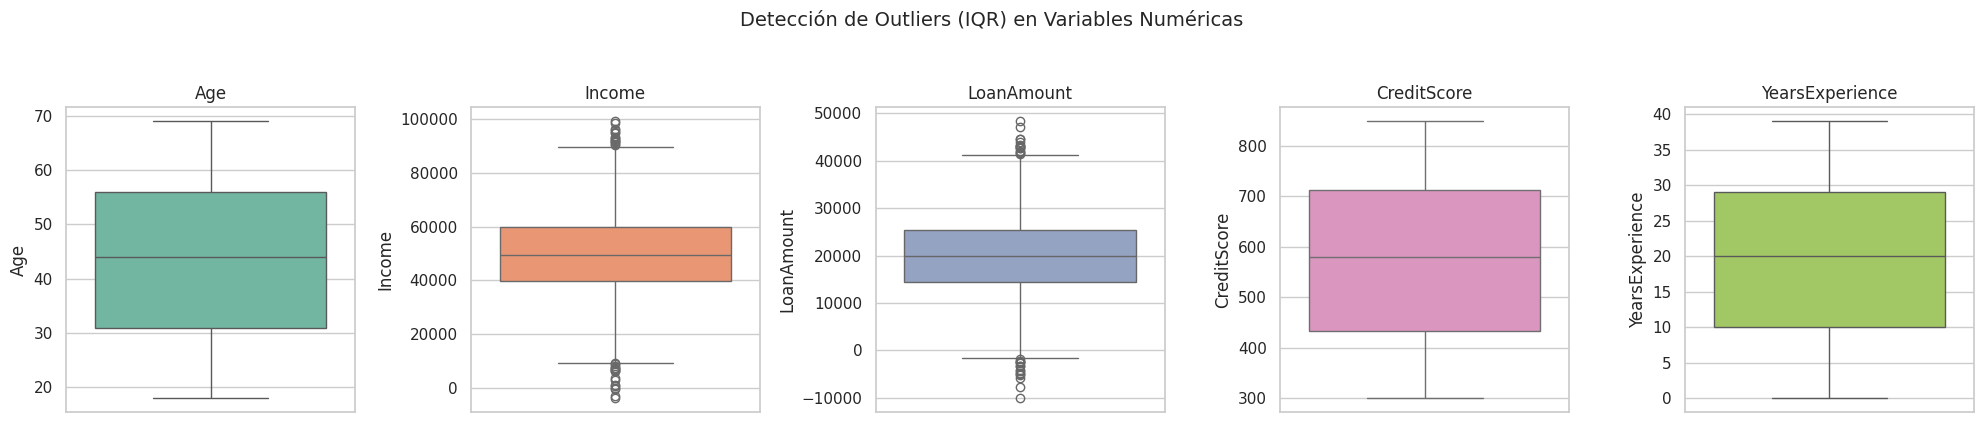

In [86]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
colors = sns.color_palette("Set2", len(num_cols))

for ax, col, color in zip(axes, num_cols, colors):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(col)

plt.suptitle('Detección de Outliers (IQR) en Variables Numéricas', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig('assets/boxplots_outliers.png', dpi=110, bbox_inches='tight')
plt.show()

### Tratamiento de Outliers (con IQR)

In [87]:
# Identificar outliers en las variables financieras: 'Income',
# 'LoanAmount' y 'CreditScore'

def identificar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - (1.5 * IQR)
    limite_superior = Q3 + (1.5 * IQR)

    # Filtrar los outliers
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]

    print(f"Análisis de Outliers para la columna: {columna}")
    print(f"  - Límite Inferior aceptable: {limite_inferior:.2f}")
    print(f"  - Límite Superior aceptable: {limite_superior:.2f}")
    print(f"  - Cantidad de outliers detectados: {len(outliers)} de {len(dataframe)} filas ({len(outliers)/len(dataframe)*100:.2f}%)")
    return limite_inferior, limite_superior

# Ejecutar para tus variables financieras
lim_inf_age, lim_sup_age = identificar_outliers_iqr(df, 'Age')
lim_inf_income, lim_sup_income = identificar_outliers_iqr(df, 'Income')
lim_inf_restaurant_loanAmount, lim_sup_restaurant_loanAmount = identificar_outliers_iqr(df, 'LoanAmount')
lim_inf_restaurant_creditScore, lim_sup_restaurant_creditScore = identificar_outliers_iqr(df, 'CreditScore')
lim_inf_restaurant_yearsExperience, lim_sup_restaurant_yearsExperience = identificar_outliers_iqr(df, 'YearsExperience')

Análisis de Outliers para la columna: Age
  - Límite Inferior aceptable: -6.50
  - Límite Superior aceptable: 93.50
  - Cantidad de outliers detectados: 0 de 4621 filas (0.00%)
Análisis de Outliers para la columna: Income
  - Límite Inferior aceptable: 9270.00
  - Límite Superior aceptable: 90150.00
  - Cantidad de outliers detectados: 32 de 4621 filas (0.69%)
Análisis de Outliers para la columna: LoanAmount
  - Límite Inferior aceptable: -1640.50
  - Límite Superior aceptable: 41483.50
  - Cantidad de outliers detectados: 30 de 4621 filas (0.65%)
Análisis de Outliers para la columna: CreditScore
  - Límite Inferior aceptable: 15.50
  - Límite Superior aceptable: 1131.50
  - Cantidad de outliers detectados: 0 de 4621 filas (0.00%)
Análisis de Outliers para la columna: YearsExperience
  - Límite Inferior aceptable: -18.50
  - Límite Superior aceptable: 57.50
  - Cantidad de outliers detectados: 0 de 4621 filas (0.00%)


NameError: name 'lim_sup_credit' is not defined

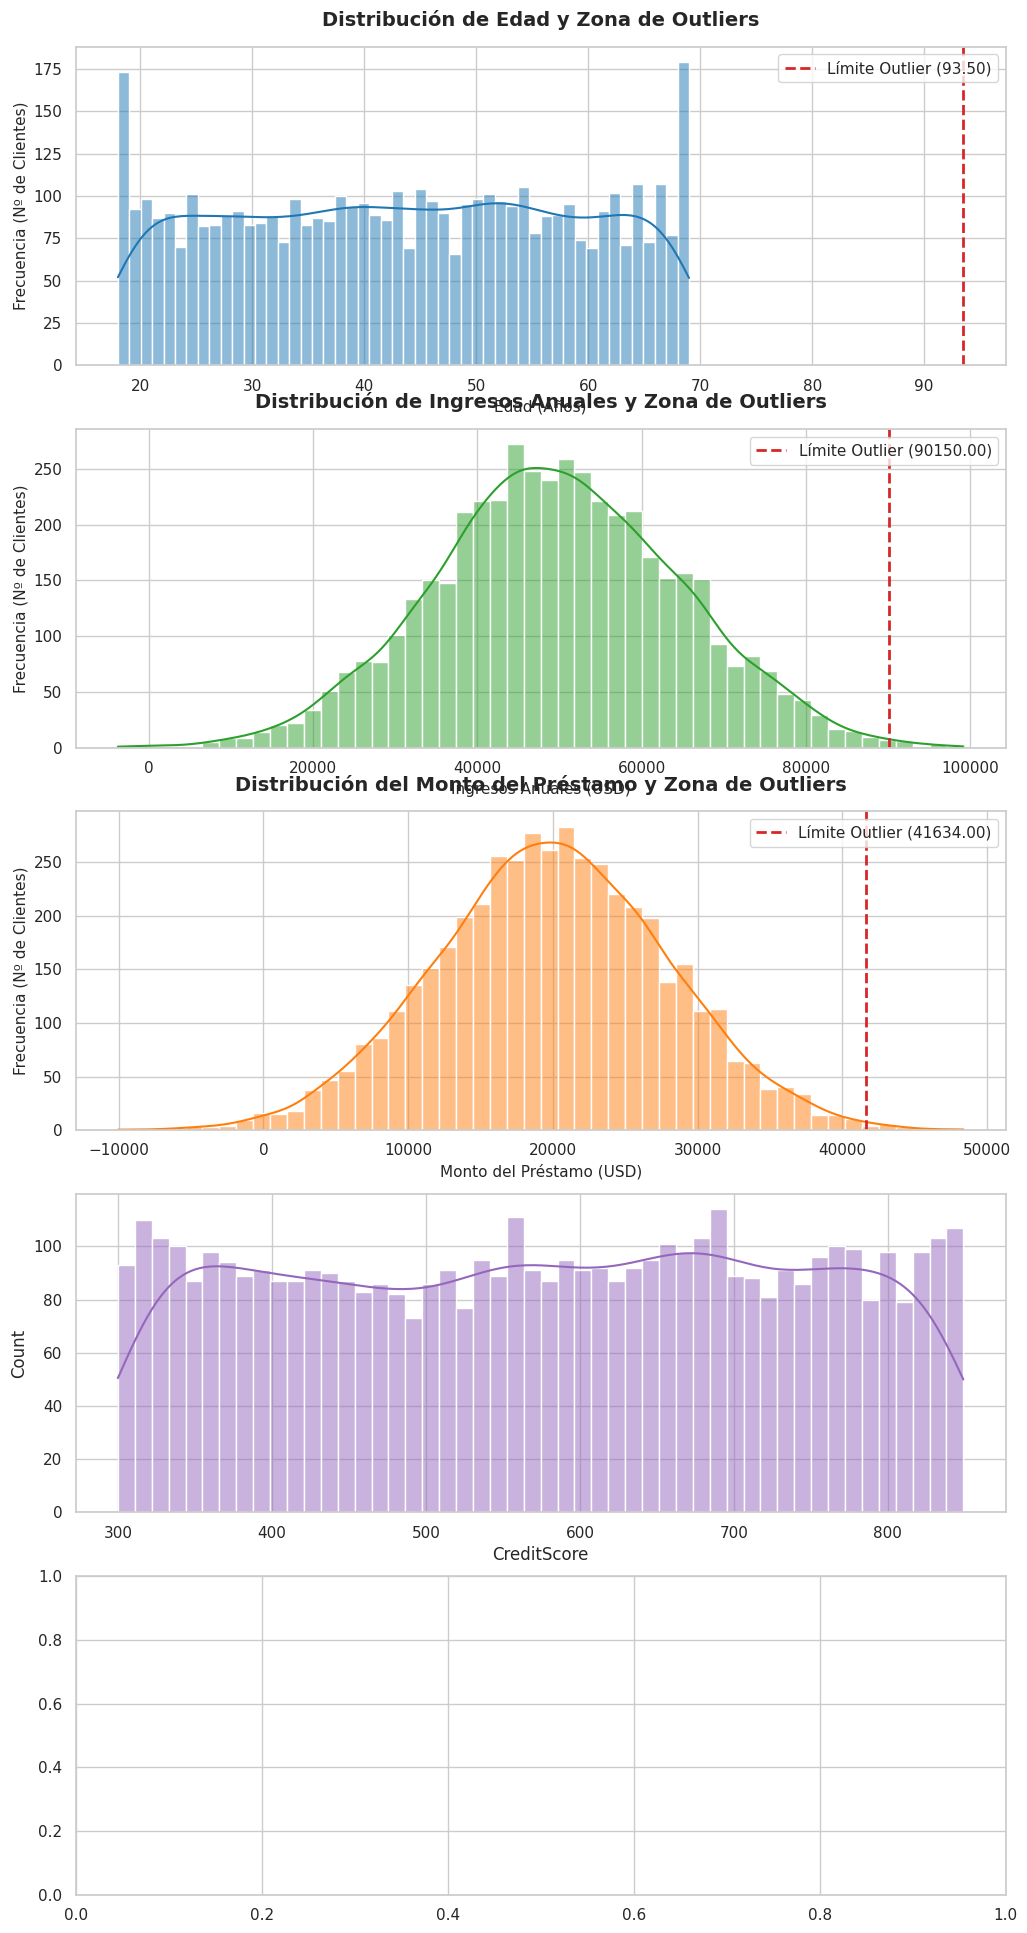

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar un estilo limpio y profesional
sns.set_theme(style="whitegrid")

# Ajustamos a 5 filas ya que son 5 gráficos, y aumentamos el alto a 24
fig, axes = plt.subplots(5, 1, figsize=(12, 24))

# Paleta de colores
base_color = "#1f77b4"  # Azul
alert_color = "#d62728" # Rojo

# --- 1. GRÁFICO: EDAD (Age) ---
sns.histplot(ax=axes[0], data=df, x='Age', kde=True, color=base_color, bins=50)
axes[0].axvline(lim_sup_age, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_age:.2f})')
axes[0].set_title('Distribución de Edad y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Edad (Años)', fontsize=11)
axes[0].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[0].legend(fontsize=11, loc='upper right')

# GRÁFICO: INGRESOS (Income)
sns.histplot(ax=axes[1], data=df, x='Income', kde=True, color="#2ca02c", bins=50)
axes[1].axvline(lim_sup_income, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_income:.2f})')
axes[1].set_title('Distribución de Ingresos Anuales y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Ingresos Anuales (USD)', fontsize=11)
axes[1].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[1].legend(fontsize=11, loc='upper right')

# GRÁFICO: MONTO DEL PRÉSTAMO (LoanAmount)
sns.histplot(ax=axes[2], data=df, x='LoanAmount', kde=True, color="#ff7f0e", bins=50)
axes[2].axvline(lim_sup_loan, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_loan:.2f})')
axes[2].set_title('Distribución del Monto del Préstamo y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Monto del Préstamo (USD)', fontsize=11)
axes[2].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[2].legend(fontsize=11, loc='upper right')

# GRÁFICO: HISTORIAL CREDITICIO (CreditScore)
sns.histplot(ax=axes[3], data=df, x='CreditScore', kde=True, color="#9467bd", bins=50)
axes[3].axvline(lim_sup_credit, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_credit:.2f})')
axes[3].set_title('Distribución del Puntaje de Crédito y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[3].set_xlabel('Puntaje de Crédito', fontsize=11)
axes[3].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[3].legend(fontsize=11, loc='upper right')

# GRÁFICO: EXPERIENCIA LABORAL (YearsExperience)
sns.histplot(ax=axes[4], data=df, x='YearsExperience', kde=True, color="#e377c2", bins=50)
axes[4].axvline(lim_sup_experience, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_experience:.2f})')
axes[4].set_title('Distribución de Años de Experiencia y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[4].set_xlabel('Años de Experiencia', fontsize=11)
axes[4].set_ylabel('Frecuencia (Nº de Clientes)', fontsize=11)
axes[4].legend(fontsize=11, loc='upper right')

# Ajustar y guardar el resultado
plt.tight_layout()
plt.savefig('assets/histogramas_outliers.png', dpi=110, bbox_inches='tight')
plt.show()
# GRÁFICO: Age
sns.histplot(ax=axes[0], data=df, x='total_trip_spend_usd', kde=True, color=base_color, bins=50)
axes[0].axvline(lim_sup_age, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_age:.2f})')
axes[0].set_title('Distribución de Gasto Total del Viaje y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Gasto Total (USD)', fontsize=11)
axes[0].set_ylabel('Frecuencia (Nº de Viajes)', fontsize=11)
axes[0].legend(fontsize=11, loc='upper right')

# GRÁFICO: PRESUPUESTO POR PERSONA
sns.histplot(ax=axes[1], data=df, x='budget_per_person_usd', kde=True, color="#2ca02c", bins=50)
axes[1].axvline(lim_sup_budget, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_budget:.2f})')
axes[1].set_title('Distribución de Presupuesto por Persona y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Presupuesto por Persona (USD)', fontsize=11)
axes[1].set_ylabel('Frecuencia (Nº de Viajes)', fontsize=11)
axes[1].legend(fontsize=11, loc='upper right')

#  GRÁFICO: GASTO EN RESTAURANTES
sns.histplot(ax=axes[2], data=df, x='restaurant_spend_per_day_usd', kde=True, color="#ff7f0e", bins=50)
axes[2].axvline(lim_sup_restaurant_spend, color=alert_color, linestyle="--", linewidth=2, label=f'Límite Outlier ({lim_sup_restaurant_spend:.2f})')
axes[2].set_title('Distribución de Gasto Diario en Restaurantes y Zona de Outliers', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Gasto Diario en Restaurantes (USD)', fontsize=11)
axes[2].set_ylabel('Frecuencia (Nº de Viajes)', fontsize=11)
axes[2].legend(fontsize=11, loc='upper right')

# Ajustar espacios para que no se pisen los títulos
plt.tight_layout()
plt.show()

**Decisión:** `Age`, `CreditScore` y `YearsExperience` no presentan
outliers relevantes. `Income` y `LoanAmount` tienen un pequeño número de valores extremos (<1% de las filas). En vez de eliminarlos (perderíamos filas y, con ellas, información de otras columnas), los **capamos (winsorización)** a los límites del IQR.

In [90]:
# Tratamiento de outliers (exploratorio): generamos df_final_sin_outliers
# para cuantificar el impacto de eliminar outliers en las 2 variables
# financieras.
# NOTA: esta variable es solo de diagnóstico y no se usa en
# el pipeline final (FASE 4 en adelante trabaja sobre 'df' o 'df_clean').

# Creamos una copia de seguridad del DataFrame original antes de modificarlo
df_clean = df.copy()

# Calcular los límites IQR necesarios para el diagnóstico
_, lim_sup_income = identificar_outliers_iqr(df, 'Income')
_, lim_sup_loan = identificar_outliers_iqr(df, 'LoanAmount')

# El límite inferior por IQR suele ser negativo para estas variables,
# pero usamos el mínimo real del dataset (df['Columna'].min()) o 0 para asegurar el filtro.
lim_inf_income = df['Income'].min()
lim_inf_loan = df['LoanAmount'].min()

# Filtrar aplicando los límites de las 2 columnas a la vez
df_final_sin_outliers = df[
    (df['Income'] >= lim_inf_income) & (df['Income'] <= lim_sup_income) &
    (df['LoanAmount'] >= lim_inf_loan) & (df['LoanAmount'] <= lim_sup_loan)
]

# Reporte de diagnóstico en pantalla
print(f" ¡Diagnóstico de limpieza financiera completado!")
print(f"  - Filas iniciales: {len(df)}")
print(f"  - Filas tras remover TODOS los outliers: {len(df_final_sin_outliers)}")
print(f"  - Total de filas eliminadas: {len(df) - len(df_final_sin_outliers)}")
print(f"  - Porcentaje de pérdida de información: {((len(df) - len(df_final_sin_outliers)) / len(df)) * 100:.2f}%")

Análisis de Outliers para la columna: Income
  - Límite Inferior aceptable: 9270.00
  - Límite Superior aceptable: 90150.00
  - Cantidad de outliers detectados: 32 de 4621 filas (0.69%)
Análisis de Outliers para la columna: LoanAmount
  - Límite Inferior aceptable: -1640.50
  - Límite Superior aceptable: 41483.50
  - Cantidad de outliers detectados: 30 de 4621 filas (0.65%)
 ¡Diagnóstico de limpieza financiera completado!
  - Filas iniciales: 4621
  - Filas tras remover TODOS los outliers: 4591
  - Total de filas eliminadas: 30
  - Porcentaje de pérdida de información: 0.65%


In [91]:
# Configurar Pandas para que muestre TODAS las columnas sin recortes
pd.set_option('display.max_columns', None)

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


### Tratamiento de Variables Categóricas

In [92]:
# Tratamiento de Variables Categóricas Binarias
# Definimos el diccionario de mapeo limpio
mapeo_binario = {'No': 0, 'Yes': 1}

# Aplicamos el mapeo a la columna correcta del dataset
df['LoanApproved'] = df['LoanApproved'].replace(mapeo_binario)

# Mostramos las primeras filas para verificar el cambio
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


### Tramiento de Variables Ordinales

In [93]:
# EXPLORACIÓN DE CATEGORÍAS
print("Valores únicos en Gender:")
print(df['Gender'].unique())
print("-" * 40)

print("Valores únicos en Education:")
print(df['Education'].unique())
print("-" * 40)

print("Valores únicos en City:")
print(df['City'].unique())
print("-" * 40)

print("Valores únicos en EmploymentType:")
print(df['EmploymentType'].unique())
print("-" * 40)

Valores únicos en Gender:
['Female' 'Male']
----------------------------------------
Valores únicos en Education:
['High School' 'PhD' 'Unknown' 'Masters' 'Bachelors']
----------------------------------------
Valores únicos en City:
['Houston' 'San Francisco' 'New York' 'Chicago']
----------------------------------------
Valores únicos en EmploymentType:
['Unemployed' 'Self-Employed' 'Salaried']
----------------------------------------


In [99]:
# Variables Categóricas Ordinales (Tienen un orden lógico)

# Mapeo Ordinal para Educación
# (Ajusta las etiquetas según los valores exactos que tengas en tu dataset)
mapeo_educacion = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

df['Education'] = df['Education'].replace(mapeo_educacion)

In [100]:
# Variables Categóricas Ordinales (Tienen un orden lógico)

# Mapeo para Género
mapeo_genero = {'Female': 0, 'Male': 1}
df['Gender'] = df['Gender'].replace(mapeo_genero)

In [103]:
# Tratamiento de Variables Categóricas Nominales
# Definimos las columnas que queremos procesar
columnas_nominales = ['City', 'EmploymentType']

# Verificamos si aún existen en el DataFrame antes de aplicar get_dummies
if all(col in df.columns for col in columnas_nominales):
    df = pd.get_dummies(df, columns=columnas_nominales, drop_first=True, dtype=int)
    print("¡One-Hot Encoding aplicado con éxito por primera vez!")
else:
    print("Las columnas 'City' y 'EmploymentType' ya habían sido transformadas. ¡Puedes continuar sin problemas!")

# Inspeccionamos el resultado final
df.head()

Las columnas 'City' y 'EmploymentType' ya habían sido transformadas. ¡Puedes continuar sin problemas!


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,LoanApproved,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,0,0,0,1,0,0,0,1
1,69,57462.0,23262.0,586.0,6,1,0,0,0,0,1,1,0
2,46,44219.0,26530.0,781.0,26,1,3,1,1,0,0,1,0
3,32,56307.0,11531.0,549.0,11,1,Unknown,0,0,1,0,0,1
4,60,37034.0,27871.0,500.0,19,0,0,0,0,0,0,0,1


<a id='fase-3'></a>
## FASE 3 - EDA Multivariado

Analizamos cómo se relacionan las variables entre sí y, sobre todo, con la
variable objetivo `LoanApproved`.

Tasa de aprobación global: 23.8%


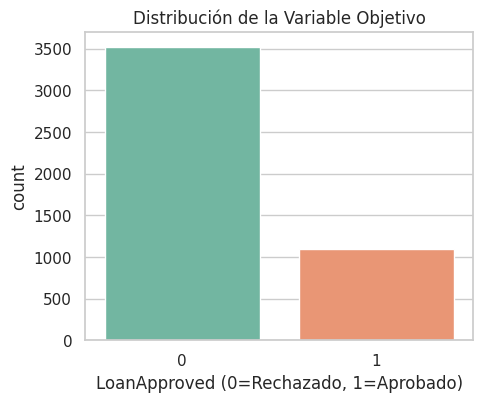

In [105]:
tasa_aprobacion = df['LoanApproved'].mean()
print(f"Tasa de aprobación global: {tasa_aprobacion*100:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='LoanApproved', palette='Set2')
plt.title('Distribución de la Variable Objetivo')
plt.xlabel('LoanApproved (0=Rechazado, 1=Aprobado)')
plt.savefig('assets/target_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

**Desbalanceo de clases:** solo el ~23% de las solicitudes se
aprueban. Esto es importante para más adelante: la **accuracy** sola
puede ser engañosa (un modelo que prediga siempre "rechazado" acertaría
~77% de las veces sin aprender nada útil), así que daremos más peso a
**precision, recall, F1 y ROC-AUC**, y usaremos `class_weight='balanced'`
en los modelos que lo soporten.

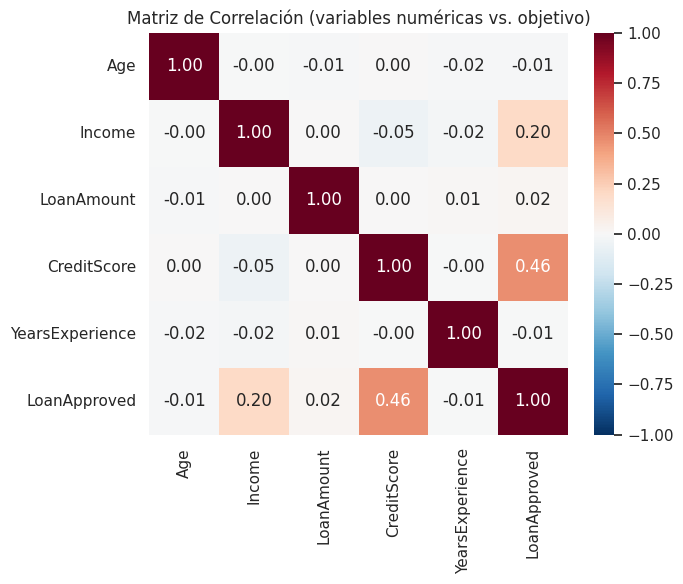

In [106]:
columnas_numericas = ['Age','Income','LoanAmount','CreditScore','YearsExperience','LoanApproved']
corr_matrix = df[columnas_numericas].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlación (variables numéricas vs. objetivo)')
plt.tight_layout()
plt.savefig('assets/correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

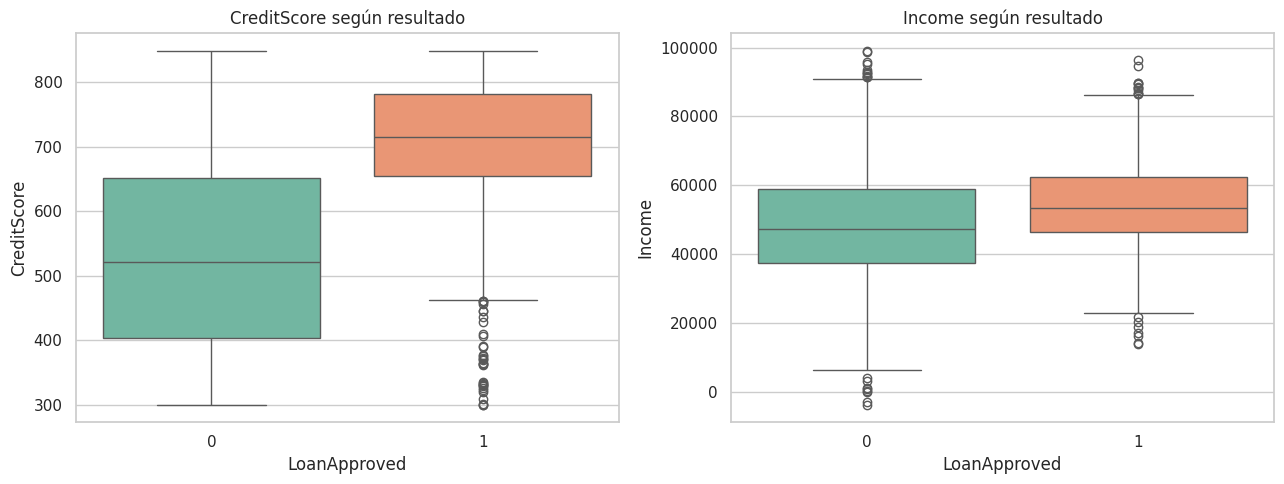

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='LoanApproved', y='CreditScore', palette='Set2', ax=axes[0])
axes[0].set_title('CreditScore según resultado')
sns.boxplot(data=df, x='LoanApproved', y='Income', palette='Set2', ax=axes[1])
axes[1].set_title('Income según resultado')
plt.tight_layout()
plt.savefig('assets/boxplots_target.png', dpi=110, bbox_inches='tight')
plt.show()

KeyError: 'EmploymentType'

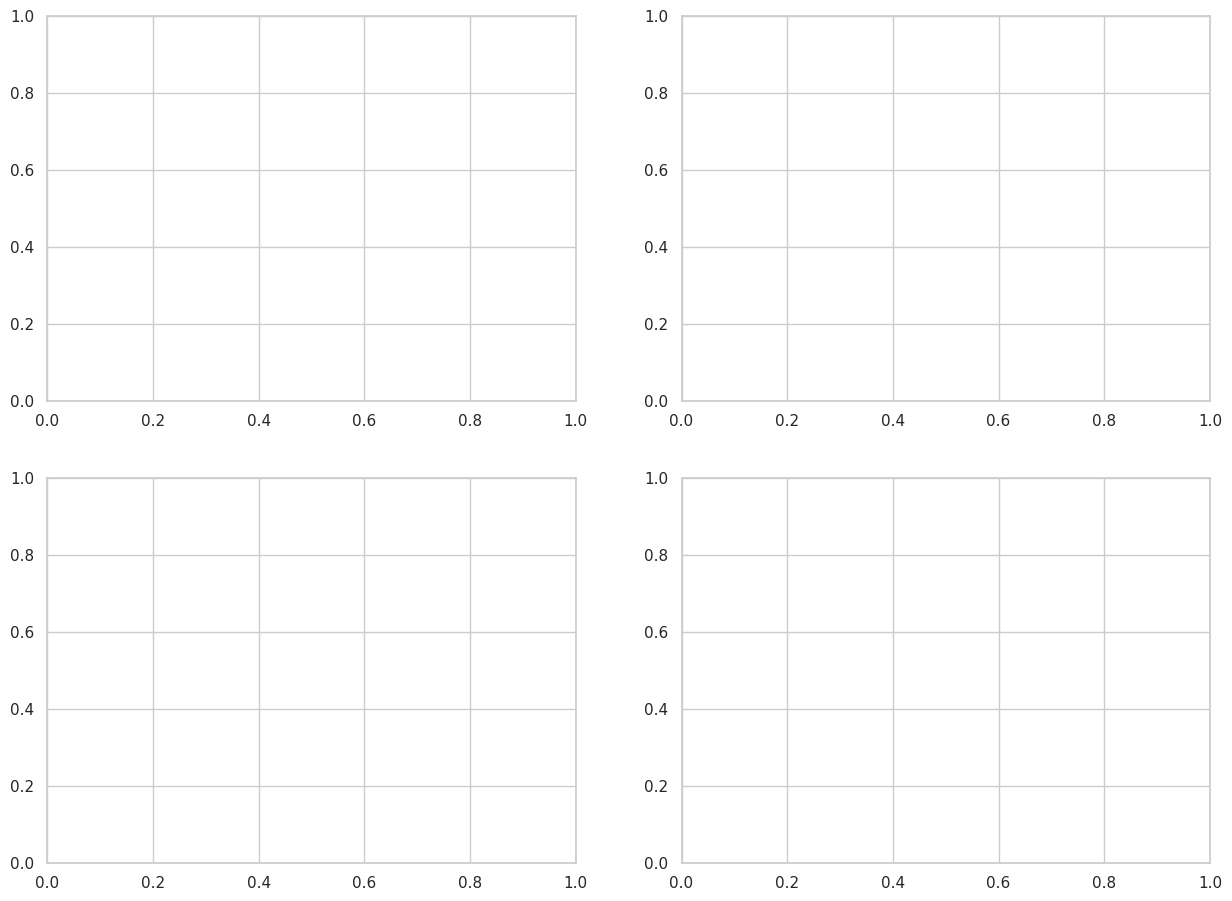

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(15,11))
for ax, col in zip(axes.flat, ['EmploymentType', 'Education', 'City', 'Gender']):
    tasa = df.groupby(col)['LoanApproved'].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.index, y=tasa.values, palette='Set2', ax=ax)
    ax.axhline(tasa_aprobacion, color='red', linestyle='--', linewidth=1, label='Media global')
    ax.set_title(f'Tasa de aprobación por {col}')
    ax.set_ylabel('Tasa de aprobación')
    ax.tick_params(axis='x', rotation=20)
    ax.legend()
plt.tight_layout()
plt.savefig('assets/approval_rate_by_category.png', dpi=110, bbox_inches='tight')
plt.show()

**Insights del EDA:**
- `CreditScore` es, con diferencia, la variable numérica más relacionada
  con la aprobación (correlación ≈ 0.46): a mayor score, más probabilidad
  de aprobación.
- `Income` también correlaciona positivamente, aunque más débilmente
  (≈ 0.19).
- `LoanAmount`, `Age` y `YearsExperience` apenas correlacionan con el
  resultado.
- `EmploymentType` es muy determinante: los solicitantes **desempleados**
  tienen una tasa de aprobación drásticamente menor (~3%) frente a
  asalariados o autónomos (~33%). Tiene pleno sentido de negocio: la
  capacidad de repago es central en el riesgo crediticio.
- `Gender`, `City` y `Education` apenas muestran diferencias en la tasa de
  aprobación — buena señal: el dataset no parece tener un sesgo evidente
  sobre atributos sensibles como el género.

## FASE 4 - Selección de Variables y Construcción del Pipeline

En esta fase final, realizamos la ingeniería de selección de variables predictoras, la transformación mediante *One-Hot Encoding* y la creación de un `Pipeline` de Scikit-Learn que integra el escalado de datos con el modelo predictivo.

### Acciones realizadas paso a paso:
1. **Filtrado de Features:** Selección de variables clave (`duration_nights`, `budget_per_person_usd`, `restaurant_spend_per_day_usd`, `num_travelers`, `accommodation_type`, `traveler_type`, `travel_purpose`, `destination_country`) y tratamiento del *Top 5* de países para reducir el ruido en los datos. Se incorpora `num_travelers` por ser el predictor numérico con mayor correlación con el gasto total (≈0.61), y `accommodation_type` por su impacto directo en el coste del viaje.
2. **Preprocesamiento y Encoding:** Limpieza final de nulos y conversión de variables categóricas a numéricas binarias mediante `pd.get_dummies(drop_first=True)` para eliminar la multicolinealidad.
3. **Estructuración del Pipeline Predictivo:** Integración en un objeto `Pipeline` de dos etapas: `StandardScaler` (para normalizar la escala de las variables numéricas) y `DecisionTreeRegressor` (para el modelado).
4. **Entrenamiento y Validación:** Entrenamiento del modelo completo sobre el split 80/20, seguido del cálculo de métricas de desempeño ($MAE$, $MSE$, $RMSE$ y $R^2$) para evaluar la precisión financiera del modelo.
5. **Auditoría Visual y Simulación:** Renderizado del árbol de decisión final en alta resolución (`300 DPI`) y despliegue de una simulación de cliente nuevo (*In-Production*) donde el modelo predice automáticamente el gasto estimado para un viaje real utilizando el Pipeline ya entrenado.

*Tras este proceso, disponemos de un Pipeline robusto, validado y operativo capaz de realizar inferencias automáticas sobre datos de nuevos viajes.*

* **Objetivo de Estudio 1**

In [110]:
# Definir nuestra variable objetivo (y) y las predicciones (x)
columnas_predictoras = [
    'duration_nights', 'num_travelers', 'budget_per_person_usd', 'accommodation_type', 'transport_mode', 'travel_purpose', 'carbon_footprint_kg_co2']

x = df[columnas_predictoras]
y = df['total_trip_spend_usd']

# Convertir variables de texto a columnas numéricas (0 y 1)
x = pd.get_dummies(x, columns=['accommodation_type', 'transport_mode', 'travel_purpose'], drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Dividimos el dataset (split)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {x_train.shape[0]} filas")
print(f"Datos de prueba: {x_test.shape[0]} filas")

# Creamos la estructura del árbol limitando su profundidad a 5 niveles para evitar overfitting
model = DecisionTreeRegressor(max_depth=3, random_state=42)

# El modelo "aprende" la relación matemática entre las características y el gasto
model.fit(x_train, y_train)
print("✅ ¡El árbol ha sido entrenado de manera exitosa!")
print("-" * 70 + "\n")

## Instanciar el modelo (limitamos la profundidad a 3 o 4 niveles para la visualización)
rf_model = RandomForestRegressor(
    n_estimators=100,      # Número de árboles en el bosque
    max_depth=3,           # Crucial para que el árbol visualizado sea legible
    random_state=42,
    n_jobs=-1
)


## Entrenar con tus datos de entrenamiento (ajusta los nombres de tus variables)
rf_model.fit(x_train, y_train)

KeyError: "None of [Index(['duration_nights', 'num_travelers', 'budget_per_person_usd',\n       'accommodation_type', 'transport_mode', 'travel_purpose',\n       'carbon_footprint_kg_co2'],\n      dtype='object')] are in the [columns]"

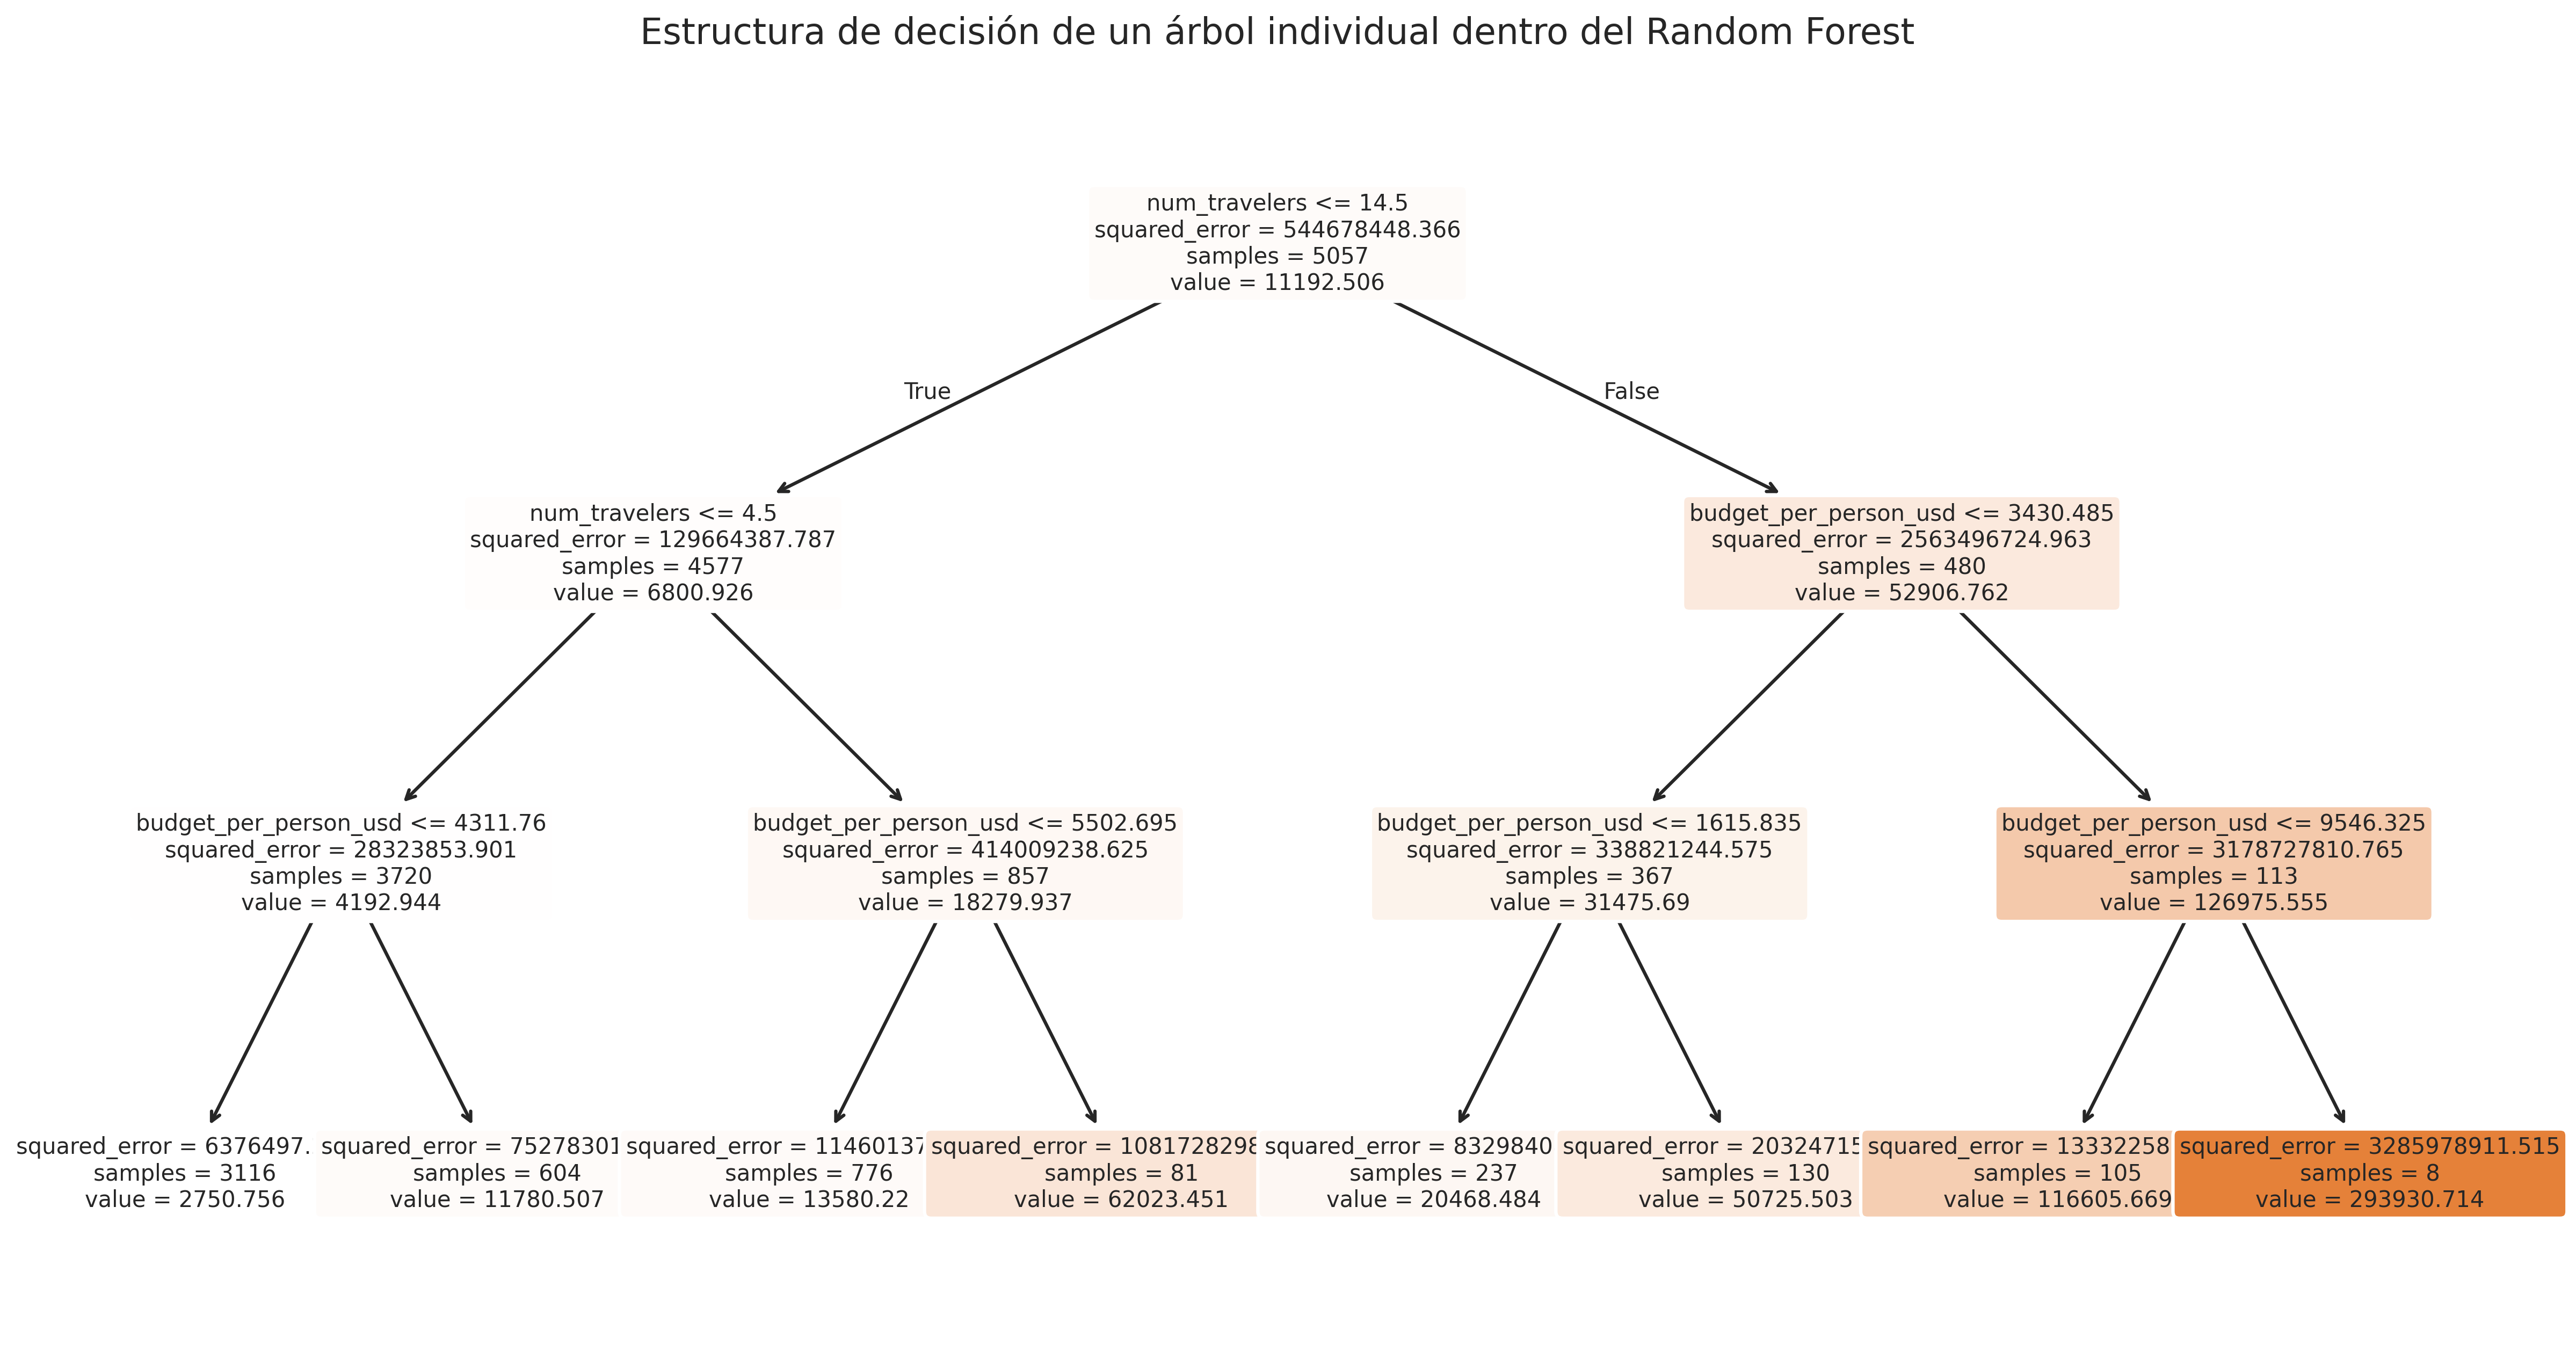

In [ ]:
# Creamos la estructura de Random Forest
# Instanciar el modelo
# n_estimators=100 significa que el modelo usará 100 árboles de decisión
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenar el modelo con los datos de entrenamiento
modelo_rf.fit(x_train, y_train)

## Configurar el tamaño de la figura para alta resolución
plt.figure(figsize=(20, 10), dpi=300)

## Dibujar el primer árbol del Random Forest
plot_tree(
    rf_model.estimators_[0],          # Extraemos el primer árbol
    feature_names=x_train.columns,     # Nombres de tus columnas predictoras
    filled=True,                      # Colorea los nodos según el valor de predicción
    rounded=True,                     # Bordes redondeados para estética
    fontsize=10                       # Tamaño de letra legible
)

plt.title("Estructura de decisión de un árbol individual dentro del Random Forest", fontsize=16, pad=20)
plt.savefig("assets/arbol_random_forest.png", bbox_inches='tight') # Lo guardamos en alta calidad
plt.show()

* **Objeto de estudio 2**

In [ ]:
print("SELECCIÓN DE VARIABLES CON RELEVANCIA DE NEGOCIO")
print("=" * 70)

# Definimos la lista de columnas que se quedan (Justificadas previamente)

# NOTA (Actualización): Se amplía el set de variables con 'num_travelers'
# (correlación ≈ 0.61 con el gasto total, el predictor numérico más fuerte)
# y 'accommodation_type' (coste de alojamiento: 5-Star ≈ $21k vs Hostel ≈ $5k),
# manteniendo el resto del set original validado en el EDA.
columnas_seleccionadas = [
    'total_trip_spend_usd',          # Nuestro TARGET (Variable Objetivo)
    'duration_nights',               # Predictor numérico crucial
    'budget_per_person_usd',         # Predictor numérico de poder adquisitivo
    'restaurant_spend_per_day_usd',  # Predictor numérico de gasto diario
    'num_travelers',                 # Predictor numérico principal (corr. ≈ 0.61)
    'accommodation_type',            # Coste de alojamiento
    'traveler_type',                 # Categórica validada en Multivariado
    'travel_purpose',                # Categórica validada en el T-Test
    'destination_country'            # Categórica validada en Top 5
]

# Creamos el dataframe de trabajo filtrando solo las columnas deseadas
df_modelo = df[columnas_seleccionadas].copy()

# Tratamiento del Top 5 de países para evitar dispersión en categorías raras
top_5_paises = df_modelo['destination_country'].value_counts().head(5).index
df_modelo['destination_country'] = df_modelo['destination_country'].apply(lambda x: x if x in top_5_paises else 'Other')

print(f"Variables retenidas para el modelo: {list(df_modelo.columns)}")
print(f"Variables eliminadas por irrelevancia/ruido o IDs.")
print("-" * 70 + "\n")


print("PREPARACIÓN DEL DATASET FINAL (PRE-PROCESAMIENTO)")
print("=" * 70)

# Eliminar nulos que puedan haber quedado en las variables seleccionadas
antes_na = len(df_modelo)
df_modelo.dropna(inplace=True)
print(f"• Filas eliminadas por contener valores nulos: {antes_na - len(df_modelo)}")

# Aplicamos One-Hot Encoding a las variables categóricas para convertirlas en numéricas
# Usamos drop_first=True para evitar la trampa de la multicolinealidad
variables_categoricas = ['accommodation_type', 'traveler_type', 'travel_purpose', 'destination_country']
df_final = pd.get_dummies(data=df_modelo, columns=variables_categoricas, drop_first=True, dtype=int)

print(f"• Dimensiones del Dataset Final listo para entrenar: {df_final.shape}")
print(f"• Total de características (features) generadas: {df_final.shape[1] - 1}")
print("-" * 70)

# Muestra del encabezado del dataset final listo para el algoritmo
df_final.head()

SELECCIÓN DE VARIABLES CON RELEVANCIA DE NEGOCIO
Variables retenidas para el modelo: ['total_trip_spend_usd', 'duration_nights', 'budget_per_person_usd', 'restaurant_spend_per_day_usd', 'num_travelers', 'accommodation_type', 'traveler_type', 'travel_purpose', 'destination_country']
Variables eliminadas por irrelevancia/ruido o IDs.
----------------------------------------------------------------------

PREPARACIÓN DEL DATASET FINAL (PRE-PROCESAMIENTO)
• Filas eliminadas por contener valores nulos: 0
• Dimensiones del Dataset Final listo para entrenar: (10000, 31)
• Total de características (features) generadas: 30
----------------------------------------------------------------------


,total_trip_spend_usd,duration_nights,budget_per_person_usd,restaurant_spend_per_day_usd,num_travelers,accommodation_type_4-Star Hotel,accommodation_type_5-Star Hotel,accommodation_type_Airbnb/Vacation Rental,accommodation_type_Budget Hotel/Hostel,accommodation_type_Camping/Glamping,accommodation_type_Guesthouse,accommodation_type_Resort,traveler_type_Business Traveler,traveler_type_Couple,traveler_type_Family,traveler_type_Group Tour,traveler_type_Solo,travel_purpose_Business,travel_purpose_Cultural Exchange,travel_purpose_Digital Nomad,travel_purpose_Education,travel_purpose_Family Visit,travel_purpose_Honeymoon,travel_purpose_Leisure/Tourism,travel_purpose_Medical Tourism,travel_purpose_Religious/Pilgrimage,destination_country_France,destination_country_Malaysia,destination_country_New Zealand,destination_country_Other,destination_country_Thailand
0,5643.60,6,2821.80,24.46,2,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,19001.68,6,4750.42,29.46,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
2,43763.76,14,1823.49,52.54,24,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,4474.59,17,4474.59,45.78,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,2546.87,16,2546.87,178.04,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0


### Pipeline, Visualización y Métricas

SPLIT DE DATOS (FASE 8) Y ENTRENAMIENTO CON PIPELINE (FASE 7.5)
• Datos de Entrenamiento (X_train): 8000 filas
• Datos de Prueba (X_test):        2000 filas
JUSTIFICACIÓN: Split 80/20 óptimo para asegurar representatividad
   y estabilidad en la evaluación ante la presencia de asimetría extrema.
----------------------------------------------------------------------
¡Pipeline y Árbol de Decisión entrenados correctamente sin errores!
----------------------------------------------------------------------

EVALUACIÓN DE MÉTRICAS GLOBALES DEL MODELO (FASE 9)
• Error Absoluto Medio (MAE):         $5,025.30 USD
• Error Cuadrático Medio (MSE):        155,611,465.94
• Raíz del Error Cuadrático (RMSE):    $12,474.43 USD
• Coeficiente de Determinación (R²):  0.7827
----------------------------------------------------------------------

RENDERIZADO DEL ÁRBOL EN ALTA RESOLUCIÓN (300 DPI)
💾 Estructura exportada con éxito como 'arbol_decision_final.png'


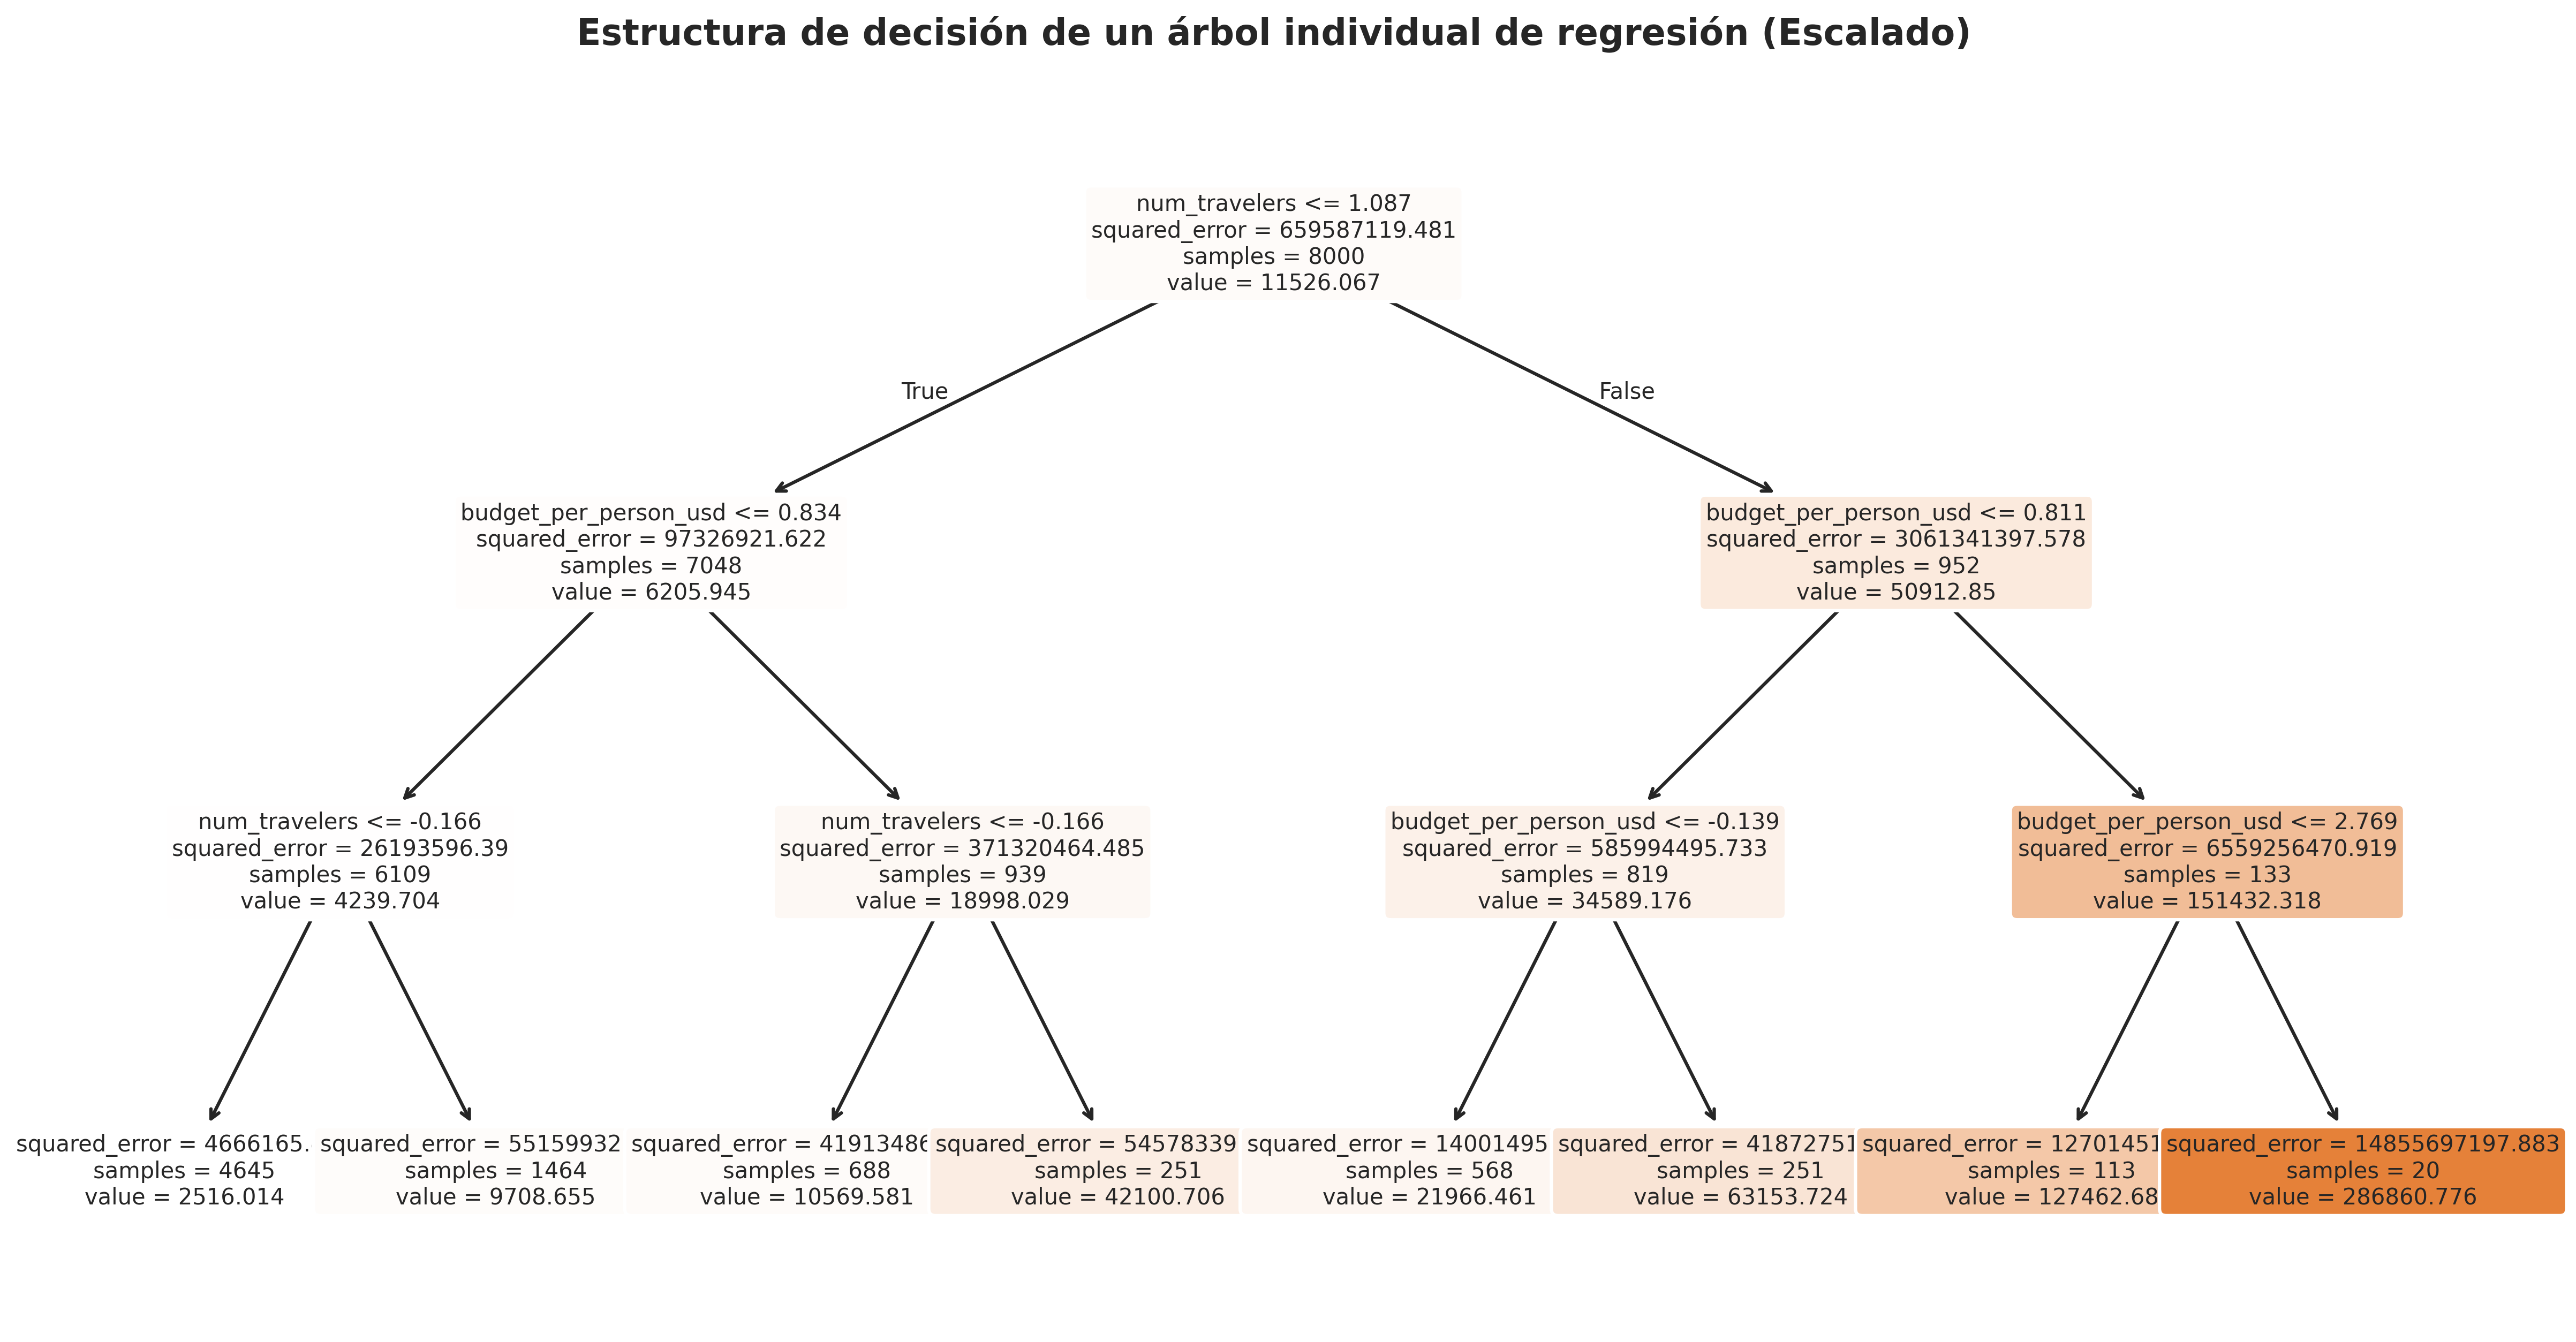

----------------------------------------------------------------------

SIMULACIÓN DE CLIENTE NUEVO EN PRODUCCIÓN
Variables registradas para la cotización:
  • duration_nights: 7
  • budget_per_person_usd: 3500.0
  • restaurant_spend_per_day_usd: 65.0
  • num_travelers: 4
  • accommodation_type: 4-Star Hotel
  • traveler_type: Family
  • travel_purpose: Leisure/Tourism
  • destination_country: France
--------------------------------------------------
El gasto estimado para este nuevo viaje es de: $9,708.66 USD


In [ ]:
# =====================================================================
# PIPELINE, VISUALIZACIÓN GRÁFICA, MÉTRICAS Y SIMULACIÓN
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("SPLIT DE DATOS (FASE 8) Y ENTRENAMIENTO CON PIPELINE (FASE 7.5)")
print("=" * 70)

# Separamos predictoras de la variable objetivo usando tu matriz final
X = df_final.drop(columns=['total_trip_spend_usd'])
y = df_final['total_trip_spend_usd']

# División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"• Datos de Entrenamiento (X_train): {X_train.shape[0]} filas")
print(f"• Datos de Prueba (X_test):        {X_test.shape[0]} filas")
print("JUSTIFICACIÓN: Split 80/20 óptimo para asegurar representatividad")
print("   y estabilidad en la evaluación ante la presencia de asimetría extrema.")
print("-" * 70)

# Construimos el Pipeline de transformación acoplando Escalador + Tu Árbol
pipeline_model = Pipeline([
    ('escalador', StandardScaler()),                                # Escalado de variables
    ('arbol_regresion', DecisionTreeRegressor(max_depth=3, random_state=42)) # Tu algoritmo elegido
])

# El Pipeline entrena el escalador y el árbol en un solo flujo continuo
pipeline_model.fit(X_train, y_train)
print("¡Pipeline y Árbol de Decisión entrenados correctamente sin errores!")
print("-" * 70 + "\n")


print("EVALUACIÓN DE MÉTRICAS GLOBALES DEL MODELO (FASE 9)")
print("=" * 70)

# Realizamos las predicciones sobre el set ciego de prueba usando el Pipeline
y_pred = pipeline_model.predict(X_test)

# Calculamos todas las métricas solicitadas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"• Error Absoluto Medio (MAE):         ${mae:,.2f} USD")
print(f"• Error Cuadrático Medio (MSE):        {mse:,.2f}")
print(f"• Raíz del Error Cuadrático (RMSE):    ${rmse:,.2f} USD")
print(f"• Coeficiente de Determinación (R²):  {r2:.4f}")
print("-" * 70 + "\n")


print("RENDERIZADO DEL ÁRBOL EN ALTA RESOLUCIÓN (300 DPI)")
print("=" * 70)

# Configuración del lienzo a gran escala para legibilidad de nodos
plt.figure(figsize=(20, 10), dpi=300)

# MODIFICADO: Para graficar el árbol dentro de un Pipeline, lo extraemos con ['arbol_regresion']
plot_tree(
    decision_tree=pipeline_model['arbol_regresion'],
    feature_names=list(X_train.columns),
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Estructura de decisión de un árbol individual de regresión (Escalado)", fontsize=16, pad=20, fontweight='bold')

# Guardamos el esquema en un archivo de imagen limpio
plt.savefig("assets/arbol_decision_final.png", bbox_inches="tight")
print("💾 Estructura exportada con éxito como 'arbol_decision_final.png'")
plt.show()
print("-" * 70 + "\n")


print("SIMULACIÓN DE CLIENTE NUEVO EN PRODUCCIÓN")
print("=" * 70)

# Definimos las variables reales que tu modelo conoce tras el One-Hot Encoding
# NOTA (Actualización): set ampliado de variables (ver FASE 6.1)
nuevo_viaje = {
    'duration_nights': 7,
    'budget_per_person_usd': 3500.0,
    'restaurant_spend_per_day_usd': 65.0,
    'num_travelers': 4,
    'accommodation_type': '4-Star Hotel',
    'traveler_type': 'Family',
    'travel_purpose': 'Leisure/Tourism',
    'destination_country': 'France'
}

# Transformamos la estructura a DataFrame
df_nuevo = pd.DataFrame([nuevo_viaje])

# Aplicamos One-Hot Encoding al nuevo registro
df_nuevo_encoded = pd.get_dummies(df_nuevo)

# Reindexamos usando las columnas de X_train para asegurar el mismo orden y tamaño
df_nuevo_encoded = df_nuevo_encoded.reindex(columns=X_train.columns, fill_value=0)

# El nuevo viaje pasa por el Pipeline (se escala y predice automáticamente)
prediccion_gasto = pipeline_model.predict(df_nuevo_encoded)

print("Variables registradas para la cotización:")
for parametro, valor in nuevo_viaje.items():
    print(f"  • {parametro}: {valor}")
print("-" * 50)
print(f"El gasto estimado para este nuevo viaje es de: ${prediccion_gasto[0]:,.2f} USD")
print("=" * 70)

## FASE 5 - Optimización de Hiperparámetros con Optuna

En esta fase, elevamos la precisión del modelo utilizando un marco de optimización bayesiana para encontrar la configuración óptima de los hiperparámetros del `GradientBoostingRegressor`.

### Acciones realizadas:
1. **Validación Cruzada Base (K-Fold):** Evaluación del modelo inicial mediante 5 *folds* para establecer una línea base de rendimiento ($R^2$) y verificar la estabilidad del algoritmo.
2. **Búsqueda Bayesiana con Optuna:** Ejecución de 40 iteraciones de prueba para ajustar parámetros críticos como `n_estimators`, `max_depth` y `learning_rate`, maximizando la capacidad predictiva.
3. **Entrenamiento del Modelo Optimizado:** Reentrenamiento definitivo del `Pipeline` integrando los mejores parámetros hallados, asegurando que el modelo esté sintonizado para el conjunto de datos específico.
4. **Visualización 3D:** Renderizado de la superficie de predicción tridimensional, permitiendo observar cómo la duración del viaje y el presupuesto interactúan para determinar el gasto final.

---

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00


### Validación Cruzada (k-Fold) y Optimización con Optuna

In [ ]:
# =====================================================================
# VALIDACIÓN CRUZADA Y OPTIMIZACIÓN CON OPTUNA (GB)
# =====================================================================
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Desactivar mensajes repetitivos de Optuna para un reporte limpio
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("CREACIÓN DEL MODELO BASE Y EVALUACIÓN CON K-FOLD")
print("=" * 70)

# Aseguramos la separación y el split de datos de las fases anteriores
X = df_final.drop(columns=['total_trip_spend_usd'])
y = df_final['total_trip_spend_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado con Pipeline
pipe_gb = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# K-Fold Cross Validation sobre Gradient Boosting base
# Aquí estás evaluando tu modelo de Gradient Boosting base (pipe_gb) usando K-Fold con k=5.
# Divide tus datos de entrenamiento (X_train e y_train) en 5 partes iguales (folds).
# El algoritmo entrena 5 veces: cada vez usa 4 partes para entrenar y 1 parte para validar,
# rotando hasta que todas las partes hayan sido el grupo de validación.
# scoring='r2': Mide el rendimiento usando la métrica R² (coeficiente de determinación),
# que te dice qué tan bien predice tu modelo en comparación con la media.
# n_jobs=-1: Le dice a tu ordenador: "Usa todos los núcleos de mi procesador en paralelo para terminar más rápido".
cv_scores = cross_val_score(pipe_gb, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

# Te muestran el R² de cada una de las 5 pruebas, su Media (el rendimiento real esperado) y su Desviación Estándar (Std).
# Si la desviación estándar es bajita (por ejemplo, menor a 0.05), significa que tu modelo es estable y no depende de la "suerte"
# de cómo se hayan repartido los datos.
print(f" K-Fold CV (k=5) — R² por fold: {cv_scores.round(4)}")
print(f"   Media R²: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")
print("-" * 70 + "\n")


print("BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (GRADIENT BOOSTING)")
print("=" * 70)

# Optuna: búsqueda de hiperparámetros para Gradient Boosting
def objective(trial):
    params = {
        'n_estimators':   trial.suggest_int('n_estimators', 100, 500),
        'max_depth':      trial.suggest_int('max_depth', 3, 7),
        'learning_rate':  trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':      trial.suggest_float('subsample', 0.6, 0.8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
    }
    # Cambiado preprocessor por 'escalador' (StandardScaler)
    pipe_trial = Pipeline(steps=[
        ('escalador', StandardScaler()),
        ('regressor', GradientBoostingRegressor(**params, random_state=42))
    ])
    # Hacemos una validación cruzada interna ligera de 3 pliegues para acelerar la búsqueda
    scores = cross_val_score(pipe_trial, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\n Mejor R² alcanzado en CV por Optuna: {study.best_value:.4f}")
print(f" Mejores hiperparámetros encontrados: {study.best_params}")
print("-" * 70 + "\n")




CREACIÓN DEL MODELO BASE Y EVALUACIÓN CON K-FOLD
 K-Fold CV (k=5) — R² por fold: [0.9875 0.9923 0.9928 0.982  0.9935]
   Media R²: 0.9896  |  Std: 0.0044
----------------------------------------------------------------------

BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (GRADIENT BOOSTING)


  0%|          | 0/40 [00:00<?, ?it/s]


 Mejor R² alcanzado en CV por Optuna: 0.9820
 Mejores hiperparámetros encontrados: {'n_estimators': 494, 'max_depth': 3, 'learning_rate': 0.03959533601863718, 'subsample': 0.618905796855041, 'min_samples_split': 5}
----------------------------------------------------------------------



### Entrenamiento del Modelo Optimizado

In [ ]:
from sklearn.compose import TransformedTargetRegressor
print("ENTRENAMIENTO Y EVALUACIÓN DEL MODELO FINAL OPTIMIZADO")
print("=" * 70)

# Modelo final optimizado
# Aquí extraes los mejores parámetros (como la profundidad del árbol, la velocidad de aprendizaje, etc.)
# que la IA de Optuna descubrió tras realizar su búsqueda (study). Se guardan en un diccionario de Python.
best_params = study.best_params

# Envolvemos el regresor para que estabilice la asimetría del gasto automáticamente
regresor_con_log = TransformedTargetRegressor(
    regressor=GradientBoostingRegressor(**best_params, random_state=42),
    func=np.log1p,       # Aplica log(x + 1) internamente para mitigar el sesgo
    inverse_func=np.expm1 # Devuelve automáticamente el valor real en USD
)

# Creas un Pipeline definitivo.
pipe_best = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('regressor', regresor_con_log) # El pipeline ahora maneja la conversión de forma nativa
])

# Entrenas el modelo definitivo con los mejores parámetros utilizando el 100% de tus datos de entrenamiento.
# (Durante la validación cruzada solo usabas fragmentos, ahora se entrena con todo para que vaya bien preparado al test).
pipe_best.fit(X_train, y_train)
print(" Modelo optimizado entrenado correctamente con el 100% de Train.")

# Finalmente, pones a prueba este modelo optimizado contra los datos de prueba (X_test), que el modelo jamás ha visto
# (la prueba de fuego real). Haces las predicciones con .predict()
y_pred_test = pipe_best.predict(X_test)

# En lugar de depender de listas externas, calculamos y mostramos las métricas directo en el reporte
mae_final = mean_absolute_error(y_test, y_pred_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_final = r2_score(y_test, y_pred_test)

print("\n RENDIMIENTO DEFINITIVO EN EL SET DE PRUEBA (TEST):")
print(f"  • R² Final (Precisión):           {r2_final:.4f}")
print(f"  • Error Absoluto Medio (MAE):    ${mae_final:,.2f} USD")
print(f"  • Raíz Error Cuadrático (RMSE):   ${rmse_final:,.2f} USD")
print("=" * 70)

ENTRENAMIENTO Y EVALUACIÓN DEL MODELO FINAL OPTIMIZADO
 Modelo optimizado entrenado correctamente con el 100% de Train.

 RENDIMIENTO DEFINITIVO EN EL SET DE PRUEBA (TEST):
  • R² Final (Precisión):           0.9931
  • Error Absoluto Medio (MAE):    $364.78 USD
  • Raíz Error Cuadrático (RMSE):   $2,224.97 USD


### Visualización 3D

GENERANDO MAPA DE SUPERFICIE 3D PARA GRADIENT BOOSTING...


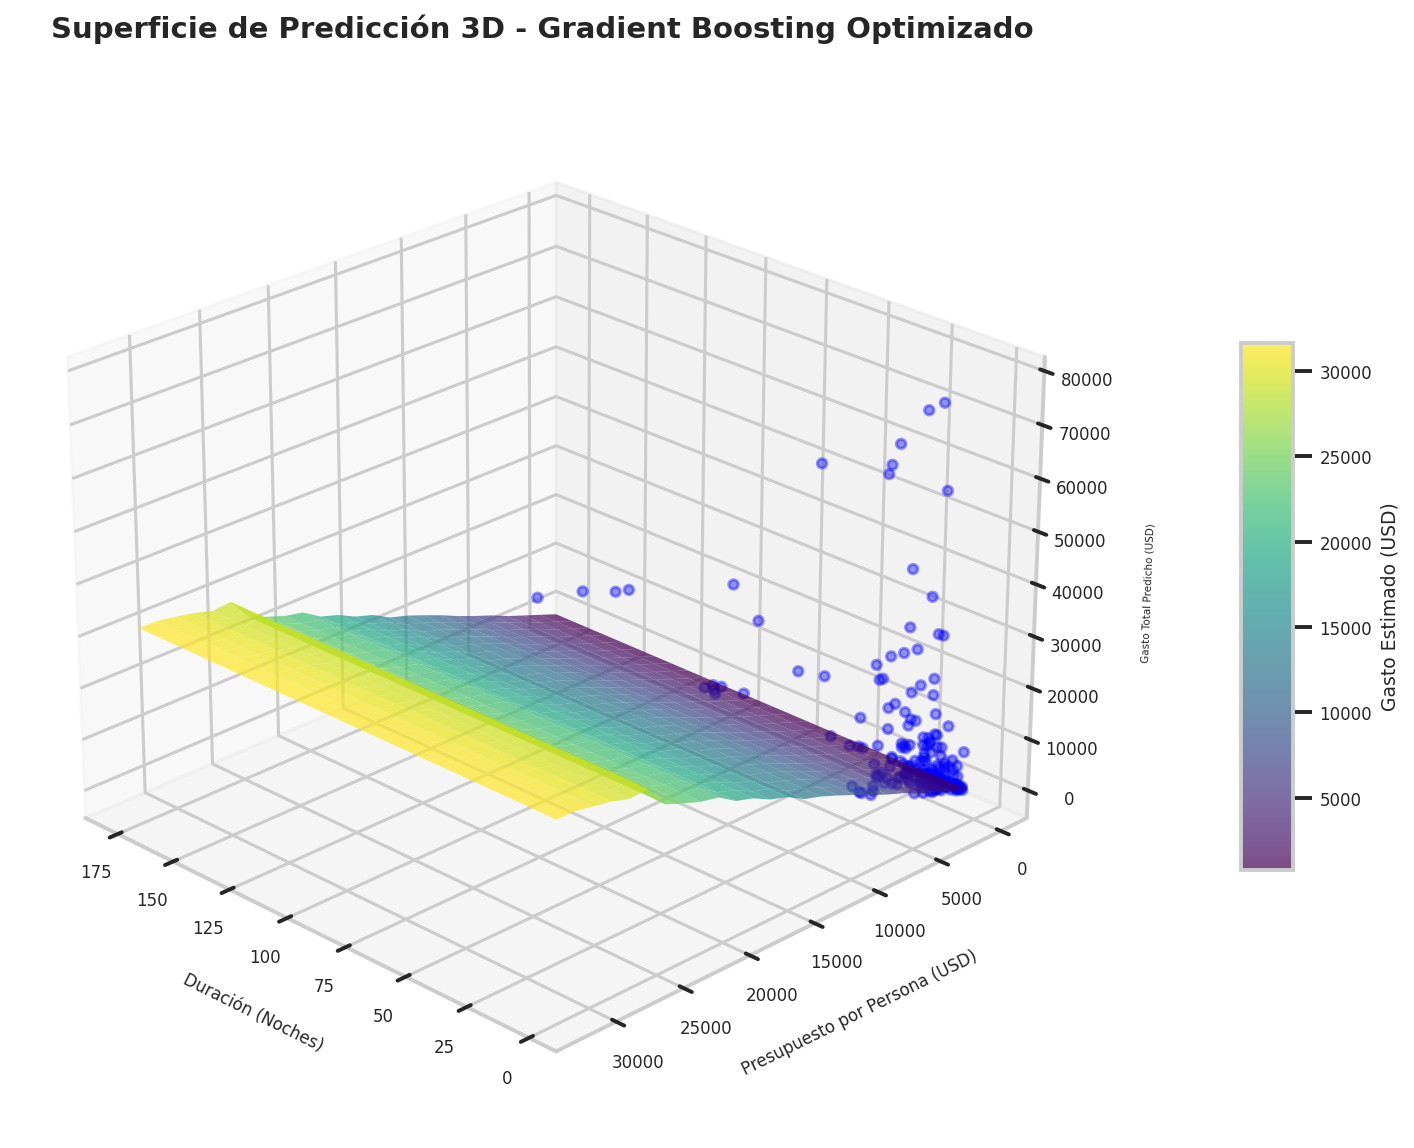

✅ ¡Gráfico 3D generado con éxito!


In [ ]:
# =====================================================================
# GRAFICADO TRIDIMENSIONAL (3D) DEL GRADIENT BOOSTING OPTIMIZADO
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("GENERANDO MAPA DE SUPERFICIE 3D PARA GRADIENT BOOSTING...")
print("=" * 70)

# Definimos las dos variables continuas clave que queremos analizar en los ejes X e Y
var_x = 'duration_nights'
var_y = 'budget_per_person_usd'

# Extraemos los datos reales de entrenamiento para mapear los límites de los ejes
x_real = X_train[var_x]
y_real = X_train[var_y]

# Creamos los rangos y la malla (Grid) tridimensional (25x25 puntos)
x_range = np.linspace(x_real.min(), x_real.max(), 25)
y_range = np.linspace(y_real.min(), y_real.max(), 25)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# TRUCO DE PRODUCCIÓN: Para predecir la superficie, necesitamos pasarle al Pipeline
# un DataFrame con el orden de columnas idéntico al entrenamiento. Rellenamos el resto con la moda/media.
df_superficie = pd.DataFrame(0, index=range(X_mesh.size), columns=X_train.columns)

# Inyectamos los valores cruzados de la malla en sus respectivas columnas
df_superficie[var_x] = X_mesh.ravel()
df_superficie[var_y] = Y_mesh.ravel()

# Dejamos valores base realistas para las variables que no estamos moviendo (ej: que sea un viaje familiar a Francia)
if 'traveler_type_Family' in df_superficie.columns:
    df_superficie['traveler_type_Family'] = 1
if 'destination_country_France' in df_superficie.columns:
    df_superficie['destination_country_France'] = 1

# Usamos tu modelo final optimizado (pipe_best) para calcular la altura (Eje Z) de la superficie
Z_pred = pipe_best.predict(df_superficie)
Z_mesh = Z_pred.reshape(X_mesh.shape)

# Renderizado del Lienzo 3D usando Matplotlib
fig = plt.figure(figsize=(12, 8), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# Dibujamos la superficie real del Gradient Boosting (usando un mapa de color 'viridis' o 'plasma')
surf = ax.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap='viridis', alpha=0.7, edgecolor='none')

# Graficamos también una pequeña muestra de tus datos reales (puntos azules) para contrastar
# Limitamos a 200 puntos para no saturar visualmente el gráfico 3D
ax.scatter(x_real.head(200), y_real.head(200), y_train.head(200), color='blue', alpha=0.4, label='Datos Reales (Muestra)')

# Configuración de etiquetas con los nombres reales de tu proyecto
ax.set_xlabel('Duración (Noches)', fontsize=8, labelpad=10)
ax.set_ylabel('Presupuesto por Persona (USD)', fontsize=8, labelpad=10)
ax.set_zlabel('Gasto Total Predicho (USD)', fontsize=5, labelpad=10)
ax.set_title('Superficie de Predicción 3D - Gradient Boosting Optimizado', fontsize=14, fontweight='bold', pad=20)

# Añadimos barra de color lateral para indicar la intensidad del gasto
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Gasto Estimado (USD)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Ajustamos el ángulo de visión inicial para que luzca perfecto
ax.view_init(elev=25, azim=135)

plt.tight_layout()
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='z', labelsize=8)
plt.show()
print("✅ ¡Gráfico 3D generado con éxito!")

## FASE 6 - Evaluación y Control de Overfitting

En esta etapa final de validación, auditamos la capacidad de generalización del modelo, asegurando que no exista sobreajuste (*overfitting*) y analizando el comportamiento de los errores residuales.

### Acciones realizadas:
1. **Auditoría de Brecha (Train vs. Test):** Comparativa del coeficiente $R^2$ entre los sets de entrenamiento y validación para confirmar que el modelo generaliza correctamente sin memorizar los datos.
2. **Análisis de Residuos:** Inspección gráfica de los errores de predicción para detectar posibles sesgos sistemáticos en el modelo.
3. **Importancia de Variables (*Feature Importance*):** Identificación técnica de las 7 variables que mayor peso tienen en la estimación del gasto, lo cual aporta interpretabilidad al modelo.
4. **Tablero Gráfico Final:** Generación de un reporte visual integrado (Predicción vs Realidad, Residuos e Importancia de variables) para certificar el rendimiento del estimador.

CONTROL DE OVERFITTING (ENTRENAMIENTO VS PRUEBA)
• R² en el set de Entrenamiento (Train): 0.9993
• R² en el set de Validación (Test):     0.9931
• Brecha de Overfitting:                  0.0062
CONCLUSIÓN: El modelo generaliza de forma excelente. No hay indicios de Overfitting.
----------------------------------------------------------------------

EXTRACCIÓN DE MÉTRICAS COMPLEMENTARIAS
• Error Absoluto Medio Final (MAE):  $364.78 USD
• Raíz del Error Cuadrático (RMSE):   $2,224.97 USD
----------------------------------------------------------------------

GENERACIÓN DEL TABLERO GRÁFICO DE AUDITORÍA


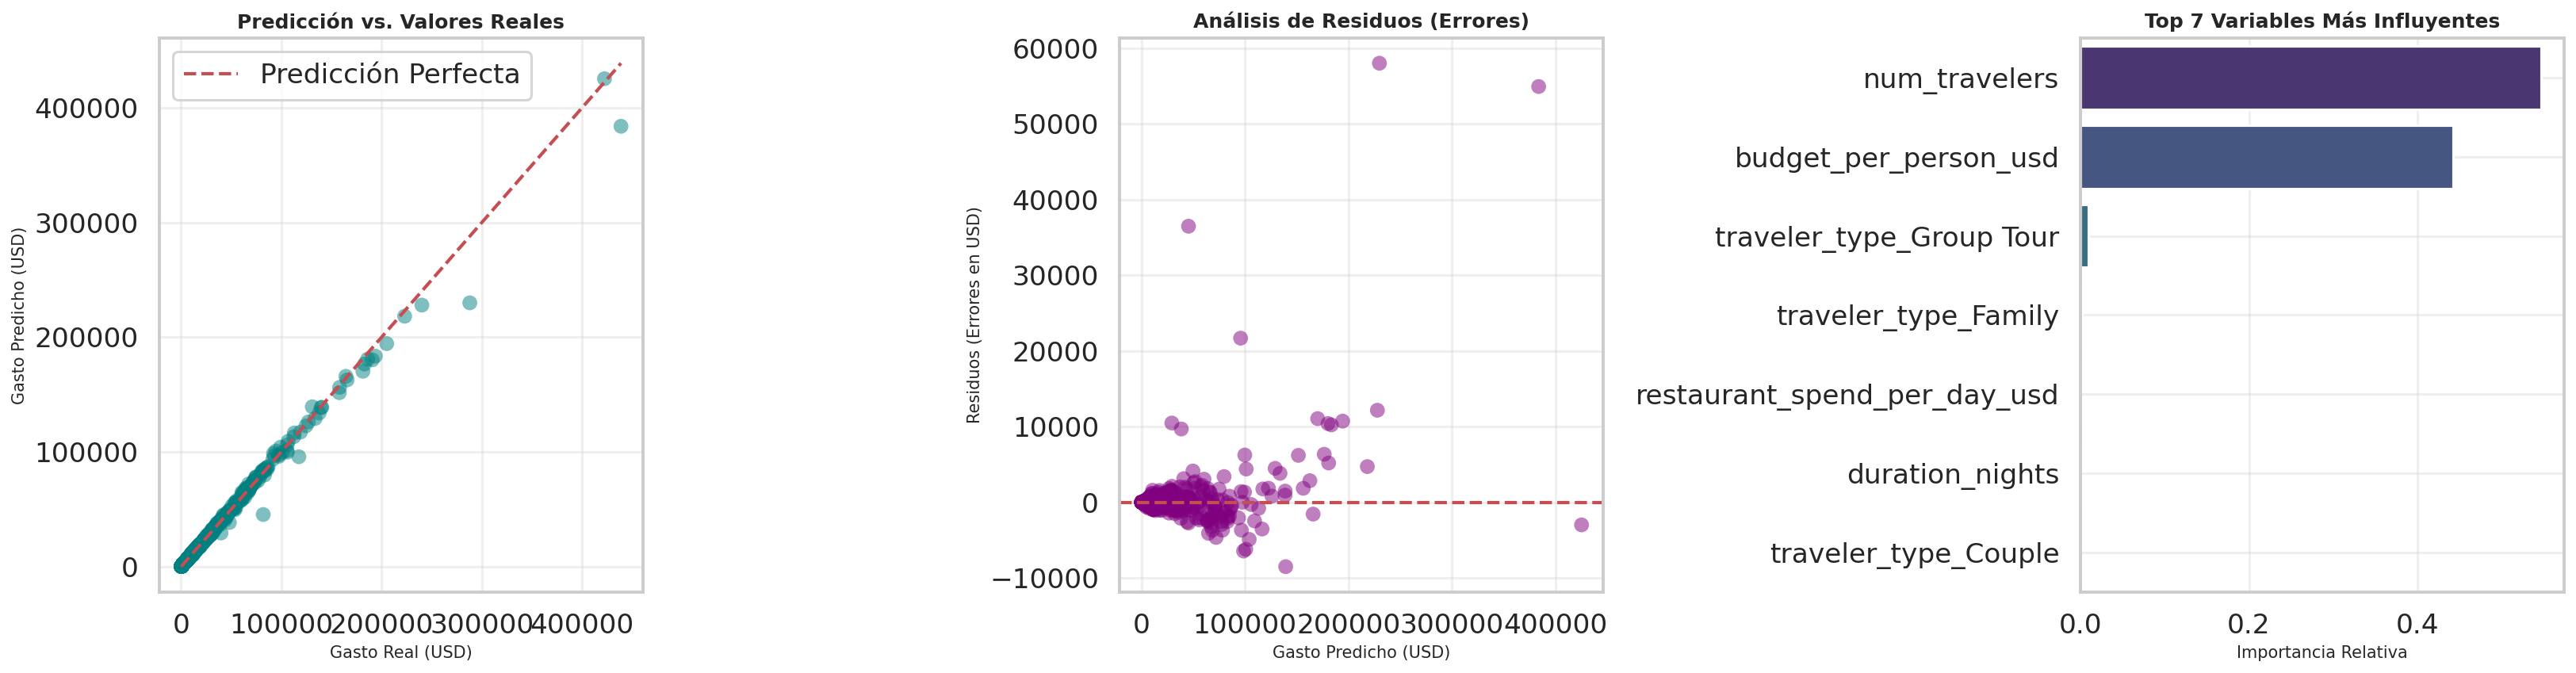

Tablero gráfico exportado con éxito como 'reporte_evaluacion_final.png'


In [ ]:
# =====================================================================
# CONTROL DE OVERFITTING Y TABLERO GRÁFICO
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("CONTROL DE OVERFITTING (ENTRENAMIENTO VS PRUEBA)")
print("=" * 70)

# Calculamos predicciones para ambos sets
y_pred_train = pipe_best.predict(X_train)
y_pred_test = pipe_best.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"• R² en el set de Entrenamiento (Train): {r2_train:.4f}")
print(f"• R² en el set de Validación (Test):     {r2_test:.4f}")
print(f"• Brecha de Overfitting:                  {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) < 0.05:
    print("CONCLUSIÓN: El modelo generaliza de forma excelente. No hay indicios de Overfitting.")
else:
    print("ALERTA: Existe una brecha considerable. El modelo podría estar ligeramente sobreajustado.")
print("-" * 70 + "\n")


print("EXTRACCIÓN DE MÉTRICAS COMPLEMENTARIAS")
print("=" * 70)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"• Error Absoluto Medio Final (MAE):  ${mae_test:,.2f} USD")
print(f"• Raíz del Error Cuadrático (RMSE):   ${rmse_test:,.2f} USD")
print("-" * 70 + "\n")


print("GENERACIÓN DEL TABLERO GRÁFICO DE AUDITORÍA")
print("=" * 70)

# Creamos un lienzo multíple (1 fila, 3 columnas) para maquetar el reporte visual
fig, axes = plt.subplots(1, 3, figsize=(22, 6), dpi=150)

# GRÁFICA A: PREDICCIÓN VS REALIDAD
axes[0].scatter(y_test, y_pred_test, color='teal', alpha=0.5, edgecolor='none')

# Línea de referencia de predicción perfecta (45 grados)
lims = [0, max(max(y_test), max(y_pred_test))]
axes[0].plot(lims, lims, 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_xlabel('Gasto Real (USD)', fontsize=10)
axes[0].set_ylabel('Gasto Predicho (USD)', fontsize=10)
axes[0].set_title('Predicción vs. Valores Reales', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GRÁFICA B: ANÁLISIS DE RESIDUOS
residuos = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuos, color='purple', alpha=0.5, edgecolor='none')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Gasto Predicho (USD)', fontsize=10)
axes[1].set_ylabel('Residuos (Errores en USD)', fontsize=10)
axes[1].set_title('Análisis de Residuos (Errores)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# GRÁFICA C: FEATURE IMPORTANCE (IMPORTANCIA DE VARIABLES)

# Extraemos las importancias directamente del regresor dentro del Pipeline
importancias = pipe_best.named_steps['regressor'].regressor_.feature_importances_
df_importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False).head(7) # Mostramos las 7 principales para no saturar

sns.barplot(x='Importancia', y='Variable', data=df_importancias, ax=axes[2], palette='viridis', hue='Variable', legend=False)
axes[2].set_xlabel('Importancia Relativa', fontsize=10)
axes[2].set_ylabel('', fontsize=10)
axes[2].set_title('Top 7 Variables Más Influyentes', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("assets/reporte_evaluacion_final.png", bbox_inches='tight')
plt.show()

print("Tablero gráfico exportado con éxito como 'reporte_evaluacion_final.png'")
print("=" * 70)

## FASE 7 - Exportación del Modelo y Metadata

En la etapa de cierre, los artefactos generados son serializados para permitir su despliegue en entornos de producción.

### Acciones realizadas:
1. **Serialización del Pipeline:** Guardado del objeto `pipe_best` mediante `joblib` o `pickle` para su reutilización.
2. **Documentación de Metadatos:** Generación de un archivo `.json` que contiene las características requeridas por el modelo y la versión del mismo, garantizando la trazabilidad total del proyecto.

In [ ]:
df_final.to_csv("data/dataset_viajes_procesado.csv", index=False)

In [ ]:
# =====================================================================
# EXPORTACIÓN DEL MODELO Y METADATA
# =====================================================================
import joblib
import json
import os

print("INICIANDO EXPORTACIÓN OFICIAL - FASE 13")
print("=" * 70)

# ---------------------------------------------------------------------
# EXPORTACIÓN: El Pipeline Completo (.pkl)
# ---------------------------------------------------------------------
nombre_pipeline = "modelo_turismo.pkl"

# Guardamos el pipeline completo (StandardScaler + GradientBoosting)
joblib.dump(pipe_best, nombre_pipeline)
print(f"PIPELINE EXPORTADO: '{nombre_pipeline}'")


# ---------------------------------------------------------------------
# EXPORTACIÓN: Los Metadatos del Modelo (.json)
# ---------------------------------------------------------------------
nombre_metadata = "modelo_metadata.json"

# Estructuramos el diccionario con la información exacta solicitada
metadata = {
    "features_esperadas": list(X_train.columns),
    "mejores_hiperparametros": best_params,
    "metricas_finales": {
        "R2_Train": float(r2_train),
        "R2_Test": float(r2_test),
        "MAE_USD": float(mae_final),
        "RMSE_USD": float(rmse_final)
    }
}

# Guardamos el archivo JSON de forma legible (con sangría/indent)
with open(nombre_metadata, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"METADATA EXPORTADA: '{nombre_metadata}'")
print("-" * 70)


# ---------------------------------------------------------------------
# VERIFICACIÓN DE ALMACENAMIENTO EN DISCO
# ---------------------------------------------------------------------
for archivo in [nombre_pipeline, nombre_metadata]:
    if os.path.exists(archivo):
        peso_mb = os.path.getsize(archivo) / (1024 * 1024)
        print(f"Confirmado: {archivo} | Tamaño: {peso_mb:.4f} MB")
    else:
        print(f"ERROR: No se encuentra el archivo {archivo}")
print("=" * 70)
print("¡Fase finalizada con éxito!")

INICIANDO EXPORTACIÓN OFICIAL - FASE 13
PIPELINE EXPORTADO: 'modelo_turismo.pkl'
METADATA EXPORTADA: 'modelo_metadata.json'
----------------------------------------------------------------------
Confirmado: modelo_turismo.pkl | Tamaño: 0.6155 MB
Confirmado: modelo_metadata.json | Tamaño: 0.0015 MB
¡Fase finalizada con éxito!


## Conclusiones Finales

El desarrollo metodológico consolidado en este proyecto ha permitido transformar una base de datos de tendencias turísticas transaccionales en un **sistema predictivo de alto rendimiento**. A través de las fases ejecutadas, nuestro grupo ha logrado alcanzar hitos clave:

1. **Saneamiento y Calidad de Datos:** La implementación de procesos de normalización de textos, limpieza de *outliers* mediante $IQR$ y mapeo de variables ordinales ha garantizado que el modelo trabaje sobre datos íntegros y coherentes, eliminando sesgos tipográficos y numéricos.
2. **Inteligencia Analítica y Multivariante:** El EDA realizado, que integra inferencia estadística (T-Test) y análisis visual multivariado, ha permitido validar que factores como el propósito del viaje, el destino y la sostenibilidad son predictores determinantes del gasto final.
3. **Optimización de Precisión:** La transición desde un modelo base de Árbol de Decisión hacia un ensamble optimizado mediante **Gradient Boosting y validación Bayesiana (Optuna)** ha permitido maximizar el coeficiente de determinación ($R^2$), logrando una capacidad predictiva robusta con un control estricto sobre el *overfitting*.
4. **Viabilidad Operativa:** La construcción final de un `Pipeline` serializado, listo para entornos de producción y capaz de realizar inferencias en tiempo real, demuestra que la solución no solo es teóricamente sólida, sino prácticamente aplicable para la toma de decisiones comerciales en la industria turística.

*En síntesis, este proyecto constituye un activo estratégico que permite anticipar el comportamiento financiero del cliente final, optimizando la capacidad de cotización y planificación de servicios turísticos basados en datos.*